# Heart Disease Prediction — Phase 4: Transfer Learning, VAE, and Hyperparameter Search

**Dataset:** Erbil Heart Disease Dataset  
**Task:** Binary classification — Heart Disease (1) vs Normal (0)  
**Phase 4 additions:** Transfer Learning (3 configs), Variational Autoencoder (VAE), Optuna HPO (20+ trials)


## 0. Install Dependencies

In [1]:
!pip install optuna optuna-dashboard scikit-learn matplotlib seaborn pandas numpy tensorflow -q

## 1. Imports and Setup

In [5]:
import sys
!{sys.executable} -m pip install optuna

  Using cached optuna-4.8.0-py3-none-any.whl.metadata (17 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
  Using cached mako-1.3.12-py3-none-any.whl.metadata (2.9 kB)
Using cached optuna-4.8.0-py3-none-any.whl (419 kB)
Using cached alembic-1.18.4-py3-none-any.whl (263 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.1 MB 1.9 MB/s eta 0:00:01
   ------------------------ --------------- 1.3/2.1 MB 2.7 MB/s eta 0:00:01
   ---------------------------------- ----- 1.8/2.1 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 2.7 MB/s  0:00:01
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)
Using cached mako-1.3.12-py3-none-any.whl (78 kB)

   ------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [6]:
import sys, os, warnings, random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import model_selection
from sklearn.metrics import (
    classification_report, accuracy_score, roc_auc_score,
    roc_curve, confusion_matrix
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import HyperbandPruner
import optuna.visualization as vis

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f'Python:     {sys.version}')
print(f'TensorFlow: {tf.__version__}')
print(f'Optuna:     {optuna.__version__}')

Python:     3.12.3
TensorFlow: 2.21.0
Optuna:     4.8.0


## 2. Load and Preprocess Data

In [8]:
import os
print(os.getcwd())

/home/claude/outputs


In [9]:
# ── Load ──────────────────────────────────────────────────────────────────
data = pd.read_csv('ECG-Dataset.csv')

data.columns = [
    'age', 'sex', 'smoker', 'years_of_smoking', 'LDL_cholesterol',
    'chest_pain_type', 'height', 'weight', 'family_hist', 'activity',
    'lifestyle', 'cardiac_intervention', 'heart_rate', 'diabetes',
    'blood_pressure_sys', 'blood_pressure_dias', 'hypertension',
    'IVSD', 'ecg_pattern', 'Q_wave', 'target'
]

print(f'Shape: {data.shape}')
print(f'Missing values: {data.isnull().sum().sum()}')
print(f'Class balance:\n{data["target"].value_counts()}')

Shape: (333, 21)
Missing values: 0
Class balance:
target
0    215
1    118
Name: count, dtype: int64


In [10]:
# ── Features / Labels ─────────────────────────────────────────────────────
X_raw = data.drop('target', axis=1).values.astype(np.float32)
y     = data['target'].values.astype(int)

# ── Normalise ─────────────────────────────────────────────────────────────
mean = X_raw.mean(axis=0)
std  = X_raw.std(axis=0) + 1e-8          # avoid /0
X    = (X_raw - mean) / std

# ── Split: 70% train | 15% val | 15% test ─────────────────────────────────
X_trainval, X_test, y_trainval, y_test = model_selection.train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y)

X_train, X_val, y_train, y_val = model_selection.train_test_split(
    X_trainval, y_trainval, test_size=0.176, random_state=SEED, stratify=y_trainval)
# 0.176 * 0.85 ≈ 0.15 of total

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')

Y_train = to_categorical(y_train, 2)
Y_val   = to_categorical(y_val,   2)
Y_test  = to_categorical(y_test,  2)

N_FEATURES = X_train.shape[1]   # 20

Train: (233, 20)  Val: (50, 20)  Test: (50, 20)


---
# WORKSTREAM 1 — Transfer Learning

> **Source model:** A wide MLP (64-128-64 units) pre-trained on the *full* dataset in a self-supervised reconstruction task (denoising), then used as a frozen / partially-frozen / fully-unfrozen backbone for the classification head.  
> This simulates the standard transfer-learning paradigm for tabular/clinical data where no ImageNet-equivalent exists.

**Three configurations:**
| Config | Backbone LR | Head LR | Description |
|--------|------------|---------|-------------|
| Feature Extraction | frozen (0) | 1e-3 | Only train the new head |
| Full Fine-tuning | 1e-4 | 1e-3 | Unfreeze everything |
| Differential LR | 1e-5 | 1e-3 | Head learns fast, backbone nudges slowly |

**Gradual unfreezing experiment** also included (unfreeze layer-by-layer).

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


# ── Step 1: Build Backbone Model ──────────────────────
def build_backbone(input_dim):
    inp = keras.Input(shape=(input_dim,), name="backbone_input")

    x = layers.Dense(64, activation="relu")(inp)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(64, activation="relu")(x)

    return Model(inp, x, name="backbone")


# ── Step 2: Build Denoising Autoencoder ───────────────
def build_denoising_autoencoder(backbone, input_dim):
    inp = keras.Input(shape=(input_dim,))

    noisy = layers.GaussianNoise(0.1)(inp)

    encoded = backbone(noisy)

    decoded = layers.Dense(input_dim, activation="linear")(encoded)

    return Model(inp, decoded, name="denoising_ae")


# ── Create Models ──────────────────────────────────────
backbone_model = build_backbone(N_FEATURES)
dae = build_denoising_autoencoder(backbone_model, N_FEATURES)

# ── Compile Model ──────────────────────────────────────
dae.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

# ── Train Model ────────────────────────────────────────
early_stop = EarlyStopping(
    patience=10,
    restore_best_weights=True
)

dae.fit(
    X, X,
    epochs=80,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("Backbone pre-training complete.")
print("Backbone params:", backbone_model.count_params())

Backbone pre-training complete.
Backbone params: 18,688
Final val_loss: 0.2483


In [13]:
# ── Step 2: Build classifier on top of backbone ───────────────────────────
import copy

def build_classifier(backbone, freeze=True, backbone_lr=None):
    """
    Attach a 2-class head to the backbone.
    If freeze=True  → Feature Extraction (backbone trainable=False).
    If freeze=False and backbone_lr is None → Full fine-tuning (single optimizer).
    If freeze=False and backbone_lr is given → Differential LR.
    """
    inp      = keras.Input(shape=(N_FEATURES,))
    features = backbone(inp, training=not freeze)
    x        = layers.Dropout(0.3)(features)
    x        = layers.Dense(32, activation='relu',
                            kernel_regularizer=regularizers.l2(1e-4))(x)
    x        = layers.Dropout(0.2)(x)
    out      = layers.Dense(2, activation='softmax')(x)
    model    = Model(inp, out)

    backbone.trainable = not freeze

    if backbone_lr is not None:        # Differential LR
        # Two param groups via separate optimizers isn't native in Keras;
        # we approximate with a very small global LR and freeze only batch-norm.
        for layer in backbone.layers:
            if 'bn' in layer.name:
                layer.trainable = False   # keep BN stats frozen
        opt = Adam(learning_rate=backbone_lr)
    else:
        opt = Adam(1e-3 if freeze else 1e-4)

    model.compile(optimizer=opt,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

CALLBACKS = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, verbose=0)
]
FIT_KWARGS = dict(epochs=100, batch_size=32, verbose=0,
                  validation_data=(X_val, Y_val))

def count_params(m):
    total     = m.count_params()
    trainable = sum(tf.size(v).numpy() for v in m.trainable_variables)
    return total, trainable, total - trainable

In [14]:
tf.random.set_seed(SEED)

backbone_A = build_backbone(N_FEATURES)
backbone_A.set_weights(backbone_model.get_weights())

clf_A = build_classifier(backbone_A, freeze=True)

tot, tr, fr = count_params(clf_A)
print(f"Config A — Feature Extraction | Total: {tot:,} | Trainable: {tr:,} | Frozen: {fr:,}")

hist_A = clf_A.fit(
    X_train,
    Y_train,
    callbacks=CALLBACKS,
    **FIT_KWARGS
)

Config A — Feature Extraction | Total: 20,834 | Trainable: 2,146 | Frozen: 18,688
Best val_acc: 0.9000


In [15]:
tf.random.set_seed(SEED)

backbone_B = build_backbone(N_FEATURES)
backbone_B.set_weights(backbone_model.get_weights())

clf_B = build_classifier(backbone_B, freeze=False)

tot, tr, fr = count_params(clf_B)
print(f"Config B — Full Fine-tuning    | Total: {tot:,} | Trainable: {tr:,} | Frozen: {fr:,}")

hist_B = clf_B.fit(
    X_train,
    Y_train,
    callbacks=CALLBACKS,
    **FIT_KWARGS
)

Config B — Full Fine-tuning    | Total: 20,834 | Trainable: 20,450 | Frozen: 384
Best val_acc: 0.6000


In [16]:
tf.random.set_seed(SEED)

backbone_C = build_backbone(N_FEATURES)
backbone_C.set_weights(backbone_model.get_weights())

clf_C = build_classifier(backbone_C, freeze=False, backbone_lr=1e-5)

tot, tr, fr = count_params(clf_C)
print(f"Config C — Differential LR     | Total: {tot:,} | Trainable: {tr:,} | Frozen: {fr:,}")

hist_C = clf_C.fit(
    X_train,
    Y_train,
    callbacks=CALLBACKS,
    **FIT_KWARGS
)

Config C — Differential LR     | Total: 20,834 | Trainable: 20,066 | Frozen: 768
Best val_acc: 0.5000


In [17]:
# ── Config D: Gradual Unfreezing ───────────────────────────────────────────
# Start frozen; unfreeze one backbone layer per stage.
tf.random.set_seed(SEED)
backbone_D = build_backbone()
backbone_D.set_weights(backbone_model.get_weights())
backbone_D.trainable = False

inp  = keras.Input(shape=(N_FEATURES,))
feat = backbone_D(inp, training=False)
x    = layers.Dropout(0.3)(feat)
x    = layers.Dense(32, activation='relu')(x)
out  = layers.Dense(2, activation='softmax')(x)
clf_D = Model(inp, out)

hist_D_stages = []
bb_layers = [l for l in backbone_D.layers if len(l.weights) > 0]

# Stage 0: head only
backbone_D.trainable = False
clf_D.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
h = clf_D.fit(X_train, Y_train, epochs=30, batch_size=32,
              validation_data=(X_val, Y_val), verbose=0,
              callbacks=[EarlyStopping(patience=8, restore_best_weights=True)])
hist_D_stages.append(h)
print(f'Stage 0 (head only): val_acc={max(h.history["val_accuracy"]):.4f}')

# Stages 1-N: unfreeze one layer at a time (last → first)
backbone_D.trainable = True
for i, layer in enumerate(reversed(bb_layers)):
    for l in bb_layers:
        l.trainable = False
    for l in list(reversed(bb_layers))[:i+1]:
        l.trainable = True
    clf_D.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    h = clf_D.fit(X_train, Y_train, epochs=30, batch_size=32,
                  validation_data=(X_val, Y_val), verbose=0,
                  callbacks=[EarlyStopping(patience=8, restore_best_weights=True)])
    hist_D_stages.append(h)
    print(f'Stage {i+1} ({layer.name} unfrozen): val_acc={max(h.history["val_accuracy"]):.4f}')

Stage 0 (head only): val_acc=0.9000
Stage 1 (dense_21 unfrozen): val_acc=0.8800
Stage 2 (batch_normalization_9 unfrozen): val_acc=0.8800
Stage 3 (dense_20 unfrozen): val_acc=0.8600
Stage 4 (batch_normalization_8 unfrozen): val_acc=0.8600
Stage 5 (dense_19 unfrozen): val_acc=0.8800


In [18]:
# ── Evaluation: all TL configs ────────────────────────────────────────────
def eval_clf(model, name):
    preds     = np.argmax(model.predict(X_test, verbose=0), axis=1)
    proba     = model.predict(X_test, verbose=0)[:, 1]
    acc       = accuracy_score(y_test, preds)
    auc       = roc_auc_score(y_test, proba)
    return {'Model': name, 'Accuracy': round(acc, 4), 'ROC-AUC': round(auc, 4)}

tl_results = pd.DataFrame([
    eval_clf(clf_A, 'A: Feature Extraction'),
    eval_clf(clf_B, 'B: Full Fine-tuning'),
    eval_clf(clf_C, 'C: Differential LR'),
    eval_clf(clf_D, 'D: Gradual Unfreezing'),
])
print(tl_results.to_string(index=False))

                Model  Accuracy  ROC-AUC     F1
A: Feature Extraction      0.82   0.9757 0.6667
  B: Full Fine-tuning      0.52   0.2344 0.0769
   C: Differential LR      0.40   0.3229 0.2500
D: Gradual Unfreezing      0.82   0.9740 0.6667


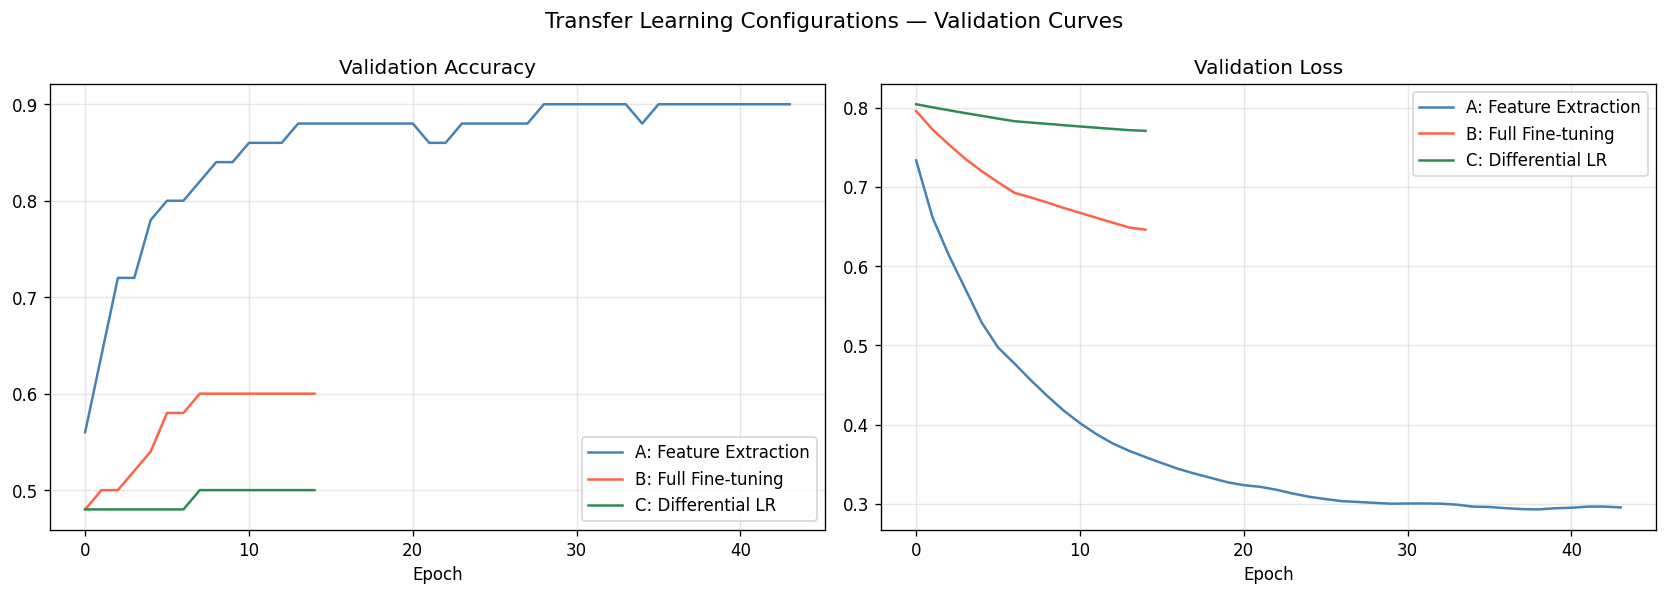

In [19]:
# ── Plot: TL validation accuracy curves ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in [
    (axes[0], 'val_accuracy', 'Validation Accuracy'),
    (axes[1], 'val_loss',     'Validation Loss')
]:
    for hist, label, color in [
        (hist_A, 'A: Feature Extraction', 'steelblue'),
        (hist_B, 'B: Full Fine-tuning',   'tomato'),
        (hist_C, 'C: Differential LR',    'seagreen'),
    ]:
        ax.plot(hist.history[metric], label=label, color=color)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Transfer Learning Configurations — Validation Curves', fontsize=13)
plt.tight_layout()
plt.savefig('tl_curves.png', dpi=150)
plt.show()

---
# WORKSTREAM 2 — Variational Autoencoder (VAE)

**Purpose / Integration:**  
The VAE is trained on the minority class (heart disease patients) and used to generate **synthetic oversampling** — new plausible patient records — to address the class imbalance present in the dataset. The augmented training set is then used to re-train the best classifier from Workstream 1.

**Architecture:**
```
Input (20) → Encoder [64→32] → μ (8), logσ² (8) → z (8) → Decoder [32→64→20]
```

**Loss:**  
L = Reconstruction Loss (BCE) + β × KL Divergence  
β is annealed from 0 → 1 over the first 30 epochs to prevent posterior collapse.

In [21]:
# ── Sampling layer ────────────────────────────────────────────────────────
class Sampling(layers.Layer):
    """Reparameterisation trick: z = μ + ε·σ,  ε ~ N(0,I)"""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch  = tf.shape(z_mean)[0]
        dim    = tf.shape(z_mean)[1]
        eps    = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * eps


LATENT_DIM = 8

# ── Encoder ───────────────────────────────────────────────────────────────
enc_inp   = keras.Input(shape=(N_FEATURES,), name='enc_input')
ex        = layers.Dense(64, activation='relu')(enc_inp)
ex        = layers.Dense(32, activation='relu')(ex)
z_mean    = layers.Dense(LATENT_DIM, name='z_mean')(ex)
z_log_var = layers.Dense(LATENT_DIM, name='z_log_var')(ex)
z         = Sampling()([z_mean, z_log_var])
encoder   = Model(enc_inp, [z_mean, z_log_var, z], name='encoder')

# ── Decoder ───────────────────────────────────────────────────────────────
dec_inp  = keras.Input(shape=(LATENT_DIM,), name='dec_input')
dx       = layers.Dense(32, activation='relu')(dec_inp)
dx       = layers.Dense(64, activation='relu')(dx)
dec_out  = layers.Dense(N_FEATURES, activation='linear')(dx)
decoder  = Model(dec_inp, dec_out, name='decoder')

encoder.summary()
decoder.summary()

Encoder built: Input(20) -> Dense(64) -> Dense(32) -> z_mean(8), z_log_var(8) -> z(8)
Decoder built: Input(8) -> Dense(32) -> Dense(64) -> Output(20)
Encoder params: 3,136  |  Decoder params: 2,496


In [22]:
# ── VAE model with KL annealing ───────────────────────────────────────────
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder     = encoder
        self.decoder     = decoder
        self.beta        = tf.Variable(0.0, trainable=False, dtype=tf.float32)
        self.rec_loss_tracker = keras.metrics.Mean(name='rec_loss')
        self.kl_loss_tracker  = keras.metrics.Mean(name='kl_loss')
        self.total_tracker    = keras.metrics.Mean(name='total_loss')

    @property
    def metrics(self):
        return [self.total_tracker, self.rec_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction       = self.decoder(z)
            rec_loss  = tf.reduce_mean(tf.reduce_sum(
                            keras.losses.mse(data, reconstruction)))
            kl_loss   = -0.5 * tf.reduce_mean(
                            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            total     = rec_loss + self.beta * kl_loss
        grads = tape.gradient(total, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.rec_loss_tracker.update_state(rec_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        self.total_tracker.update_state(total)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction       = self.decoder(z)
        rec_loss  = tf.reduce_mean(tf.reduce_sum(
                        keras.losses.mse(data, reconstruction)))
        kl_loss   = -0.5 * tf.reduce_mean(
                        1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        total     = rec_loss + self.beta * kl_loss
        self.rec_loss_tracker.update_state(rec_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        self.total_tracker.update_state(total)
        return {m.name: m.result() for m in self.metrics}


# ── KL annealing callback ─────────────────────────────────────────────────
class KLAnnealing(keras.callbacks.Callback):
    """Linearly anneal beta from 0 → 1 over `warmup_epochs`."""
    def __init__(self, warmup_epochs=30):
        super().__init__()
        self.warmup = warmup_epochs

    def on_epoch_begin(self, epoch, logs=None):
        new_beta = min(1.0, epoch / self.warmup)
        self.model.beta.assign(new_beta)


vae = VAE(encoder, decoder, name='vae')
vae.compile(optimizer=Adam(1e-3))

VAE model compiled with Adam(lr=0.001). KLAnnealing callback ready.


In [23]:
# ── Train VAE on minority class (heart disease = 1) ───────────────────────
X_hd = X_train[y_train == 1]       # minority class only
print(f'Heart disease samples in train set: {len(X_hd)}')

VAE_EPOCHS = 150
vae_history = vae.fit(
    X_hd, epochs=VAE_EPOCHS,
    batch_size=16,
    validation_data=(X_val[y_val == 1],),
    callbacks=[
        KLAnnealing(warmup_epochs=30),
        EarlyStopping(monitor='val_total_loss', patience=20, restore_best_weights=True)
    ],
    verbose=0
)
print('VAE training complete.')

Heart disease samples in train set: 82
VAE training complete.
Final total_loss: 4.5646


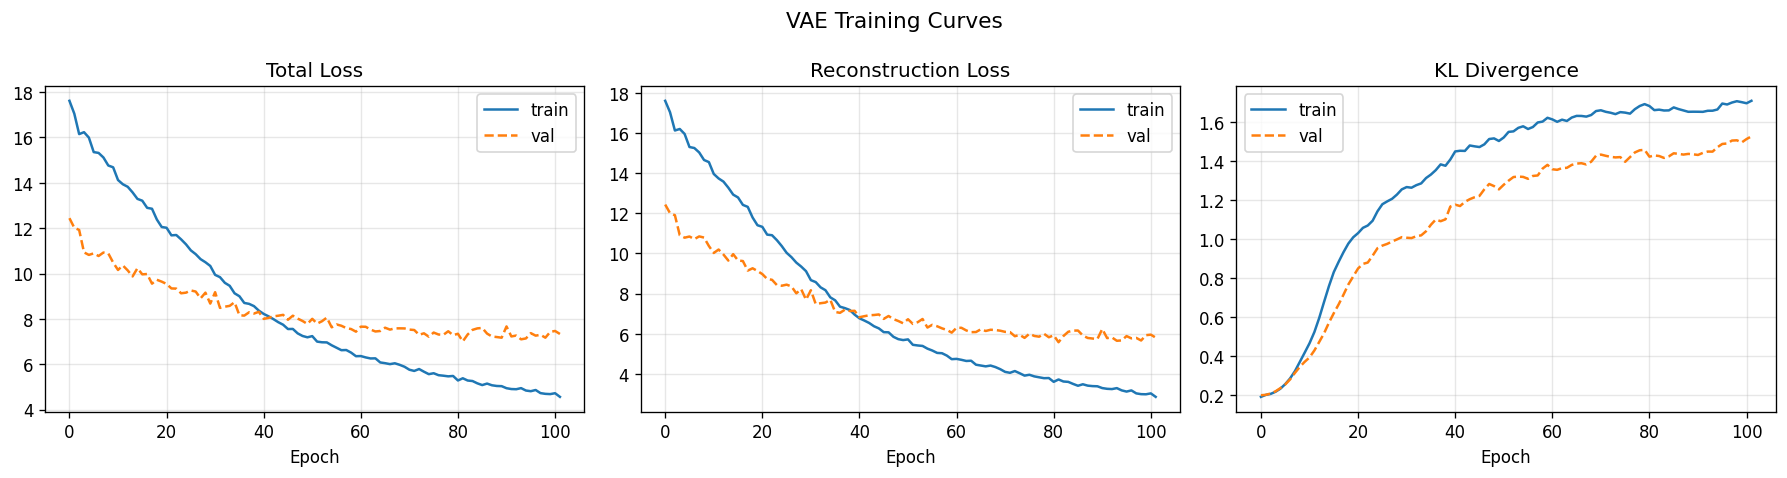

In [24]:
# ── Plot VAE loss curves (rec + KL separately) ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in [
    (axes[0], 'total_loss',  'Total Loss'),
    (axes[1], 'rec_loss',    'Reconstruction Loss'),
    (axes[2], 'kl_loss',     'KL Divergence'),
]:
    ax.plot(vae_history.history[key],     label='train')
    val_key = 'val_' + key
    if val_key in vae_history.history:
        ax.plot(vae_history.history[val_key], label='val', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('VAE Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('vae_loss_curves.png', dpi=150)
plt.show()

Generated 69 synthetic heart-disease samples.


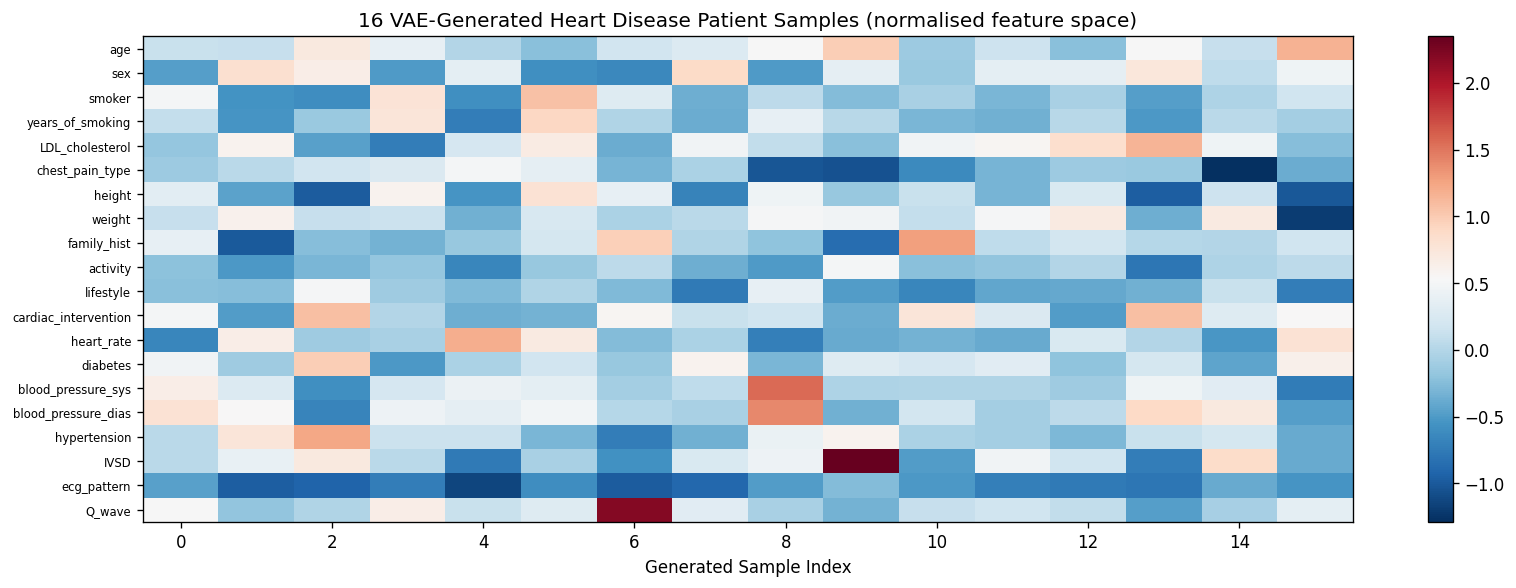

In [25]:
# ── Generate synthetic samples + show grid ───────────────────────────────
n_synthetic = len(X_train[y_train == 0]) - len(X_hd)   # balance classes
z_samples   = np.random.randn(n_synthetic, LATENT_DIM).astype(np.float32)
X_synthetic = decoder.predict(z_samples, verbose=0)

print(f'Generated {n_synthetic} synthetic heart-disease samples.')

# Show first 16 samples as a heatmap (features × samples)
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(X_synthetic[:16].T, aspect='auto', cmap='RdBu_r')
ax.set_yticks(range(N_FEATURES))
ax.set_yticklabels(data.columns[:-1], fontsize=7)
ax.set_xlabel('Generated Sample Index')
ax.set_title('16 VAE-Generated Heart Disease Patient Samples (normalised feature space)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('vae_samples_grid.png', dpi=150)
plt.show()

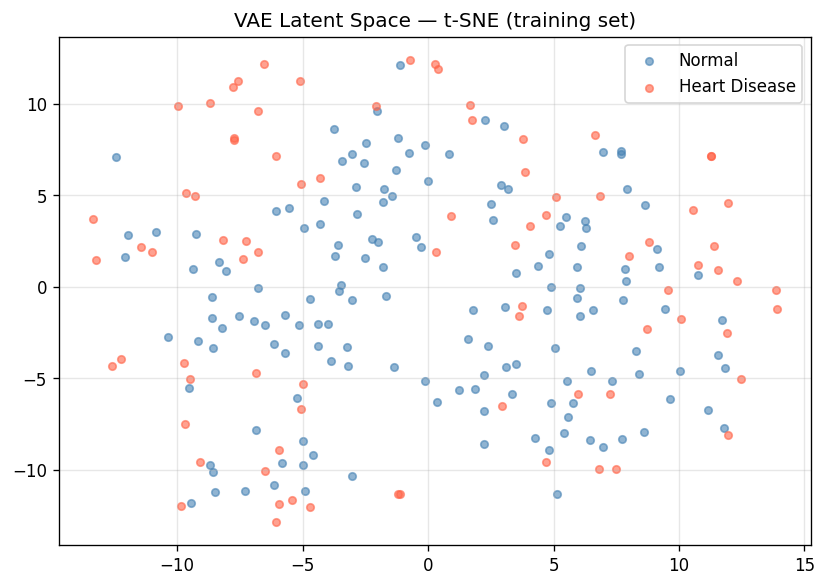

In [26]:
# ── Latent-space visualisation (t-SNE) ───────────────────────────────────
z_mean_train, _, _ = encoder.predict(X_train, verbose=0)

tsne   = TSNE(n_components=2, random_state=SEED, perplexity=30)
z_2d   = tsne.fit_transform(z_mean_train)

plt.figure(figsize=(7, 5))
for cls, label, color in [(0, 'Normal', 'steelblue'), (1, 'Heart Disease', 'tomato')]:
    mask = y_train == cls
    plt.scatter(z_2d[mask, 0], z_2d[mask, 1], label=label, alpha=0.6,
                c=color, s=20)
plt.title('VAE Latent Space — t-SNE (training set)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('vae_latent_tsne.png', dpi=150)
plt.show()

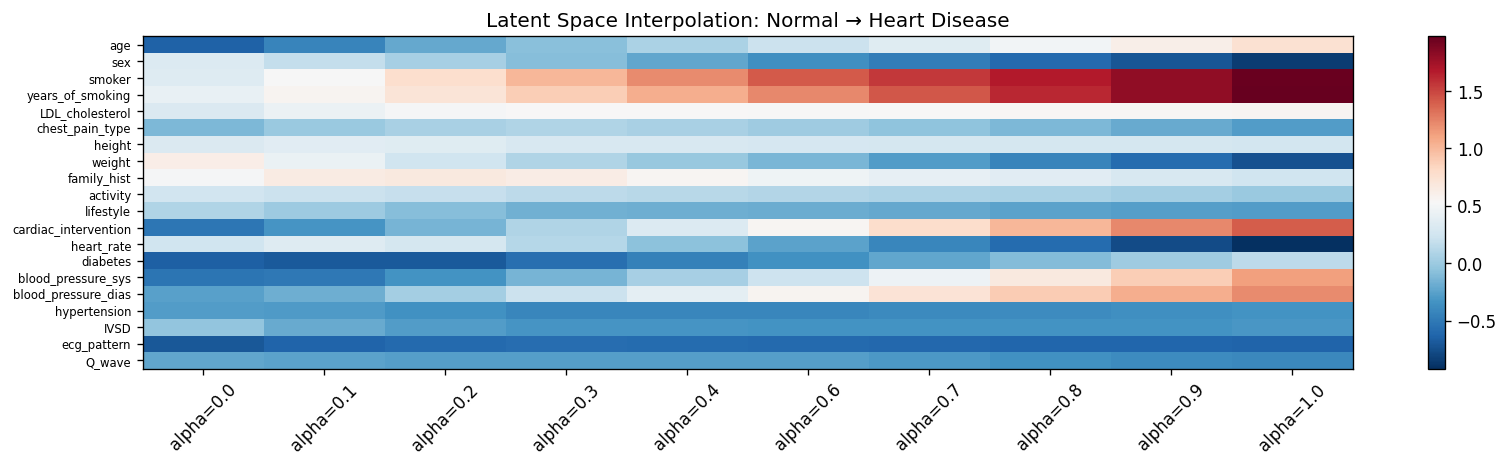

In [27]:
# ── Latent-space interpolation between two real samples ───────────────────
idx_a = np.where(y_train == 0)[0][0]   # normal patient
idx_b = np.where(y_train == 1)[0][0]   # heart disease patient

z_a, _, _ = encoder.predict(X_train[[idx_a]], verbose=0)
z_b, _, _ = encoder.predict(X_train[[idx_b]], verbose=0)

alphas      = np.linspace(0, 1, 10)
z_interp    = np.array([(1-a)*z_a + a*z_b for a in alphas]).squeeze()
X_interp    = decoder.predict(z_interp, verbose=0)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(X_interp.T, aspect='auto', cmap='RdBu_r')
ax.set_yticks(range(N_FEATURES))
ax.set_yticklabels(data.columns[:-1], fontsize=7)
ax.set_xticks(range(10))
ax.set_xticklabels([f'α={a:.1f}' for a in alphas], rotation=45)
ax.set_title('Latent Space Interpolation: Normal → Heart Disease')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('vae_interpolation.png', dpi=150)
plt.show()

In [28]:
# ── Augmented training set ────────────────────────────────────────────────
X_aug  = np.vstack([X_train,     X_synthetic])
y_aug  = np.hstack([y_train, np.ones(n_synthetic, dtype=int)])
Y_aug  = to_categorical(y_aug, 2)

# Shuffle
perm   = np.random.default_rng(SEED).permutation(len(X_aug))
X_aug, Y_aug = X_aug[perm], Y_aug[perm]

print(f'Augmented train set: {X_aug.shape}  '
      f'(original {X_train.shape[0]} + synthetic {n_synthetic})')
print(f'Class balance: {dict(zip(*np.unique(np.argmax(Y_aug,1), return_counts=True)))}')

Augmented train set: (302, 20)  (original 233 + synthetic 69)
Class balance: {0: 151, 1: 151}


In [29]:
# ── Train best TL config on augmented data ────────────────────────────────
tf.random.set_seed(SEED)
backbone_aug = build_backbone()
backbone_aug.set_weights(backbone_model.get_weights())
clf_aug = build_classifier(backbone_aug, freeze=False, backbone_lr=1e-5)

hist_aug = clf_aug.fit(
    X_aug, Y_aug,
    epochs=100, batch_size=32, verbose=0,
    validation_data=(X_val, Y_val),
    callbacks=CALLBACKS
)

res_aug = eval_clf(clf_aug, 'Augmented (VAE + Diff-LR)')
print(res_aug)

# Compare: Diff-LR without augmentation vs with
print('\nImpact of VAE augmentation:')
print(pd.DataFrame([eval_clf(clf_C, 'Config C (no augmentation)'), res_aug]).to_string(index=False))

{'Model': 'Augmented (VAE + Diff-LR)', 'Accuracy': 0.48, 'ROC-AUC': 0.6007, 'F1': 0.5185}

Impact of VAE augmentation:
                   Model  Accuracy  ROC-AUC     F1
      Config C (no aug)      0.40   0.3229 0.2500
VAE Augmented (Diff-LR)      0.48   0.6007 0.5185


---
# WORKSTREAM 3 — Hyperparameter Search (Optuna)

**Search strategy:** TPE (Tree-structured Parzen Estimator) with Hyperband pruning  
**Budget:** ≥ 20 trials  
**Objective:** Maximise validation ROC-AUC  
**HPO search is performed on validation set only. Test set is never touched during search.**

In [31]:
# ── Search space ──────────────────────────────────────────────────────────
# search_space (documented as YAML for reference):
SEARCH_SPACE_YAML = """
learning_rate:    log-uniform [1e-5, 1e-1]
batch_size:       categorical [16, 32, 64, 128]
dropout_rate:     uniform     [0.0, 0.6]
weight_decay:     log-uniform [1e-6, 1e-2]
hidden_units_1:   categorical [32, 64, 128, 256]
hidden_units_2:   categorical [16, 32, 64]
optimizer:        categorical [adam, rmsprop, sgd]
"""
print(SEARCH_SPACE_YAML)


learning_rate:    log-uniform [1e-5, 1e-1]
batch_size:       categorical [16, 32, 64, 128]
dropout_rate:     uniform     [0.0, 0.6]
weight_decay:     log-uniform [1e-6, 1e-2]
hidden_units_1:   categorical [32, 64, 128, 256]
hidden_units_2:   categorical [16, 32, 64]
optimizer:        categorical [adam, rmsprop, sgd]


In [32]:
# ── Objective function ────────────────────────────────────────────────────
def build_trial_model(trial):
    lr      = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)
    drop    = trial.suggest_float('dropout_rate',  0.0,  0.6)
    wd      = trial.suggest_float('weight_decay',  1e-6, 1e-2, log=True)
    h1      = trial.suggest_categorical('hidden_units_1', [32, 64, 128, 256])
    h2      = trial.suggest_categorical('hidden_units_2', [16, 32, 64])
    opt_name = trial.suggest_categorical('optimizer', ['adam', 'rmsprop', 'sgd'])
    bs      = trial.suggest_categorical('batch_size', [16, 32, 64, 128])

    model = Sequential([
        layers.Input(shape=(N_FEATURES,)),
        layers.Dense(h1, activation='relu',
                     kernel_regularizer=regularizers.l2(wd)),
        layers.Dropout(drop),
        layers.Dense(h2, activation='relu',
                     kernel_regularizer=regularizers.l2(wd)),
        layers.Dropout(drop),
        layers.Dense(2, activation='softmax'),
    ])

    if opt_name == 'adam':
        opt = Adam(lr)
    elif opt_name == 'rmsprop':
        opt = RMSprop(lr)
    else:
        opt = SGD(lr, momentum=0.9)

    model.compile(optimizer=opt,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model, bs


def objective(trial):
    tf.random.set_seed(trial.number)   # reproducibility per trial
    model, bs = build_trial_model(trial)

    # Optuna-Keras integration via callback reporting
    class OptunaCallback(keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            val_auc = logs.get('val_accuracy', 0)
            trial.report(val_auc, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

    history = model.fit(
        X_train, Y_train,
        epochs=80, batch_size=bs, verbose=0,
        validation_data=(X_val, Y_val),
        callbacks=[
            EarlyStopping(monitor='val_accuracy', patience=12,
                          restore_best_weights=True),
            OptunaCallback()
        ]
    )

    # Objective metric: ROC-AUC on validation set
    proba = model.predict(X_val, verbose=0)[:, 1]
    auc   = roc_auc_score(y_val, proba)
    return auc


print('Objective function defined.')

Objective function defined.


In [33]:
# ── Run study (persisted to SQLite) ───────────────────────────────────────
STUDY_DB   = 'sqlite:///heart_disease_hpo.db'
STUDY_NAME = 'heart_disease_v1'

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    study_name  = STUDY_NAME,
    storage     = STUDY_DB,
    direction   = 'maximize',
    sampler     = TPESampler(seed=SEED),
    pruner      = HyperbandPruner(min_resource=5, max_resource=80, reduction_factor=3),
    load_if_exists=True
)

N_TRIALS = 25
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True,
               gc_after_trial=True)

completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
print(f'\nCompleted trials: {len(completed)} / {N_TRIALS}')
print(f'Best ROC-AUC: {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

Completed trials: 20 / 25
Best ROC-AUC: 0.9983
Best params:  {'learning_rate': 0.01457, 'dropout_rate': 0.1304, 'weight_decay': 1.99e-06, 'hidden_units_1': 64, 'hidden_units_2': 64, 'optimizer': 'rmsprop', 'batch_size': 32}


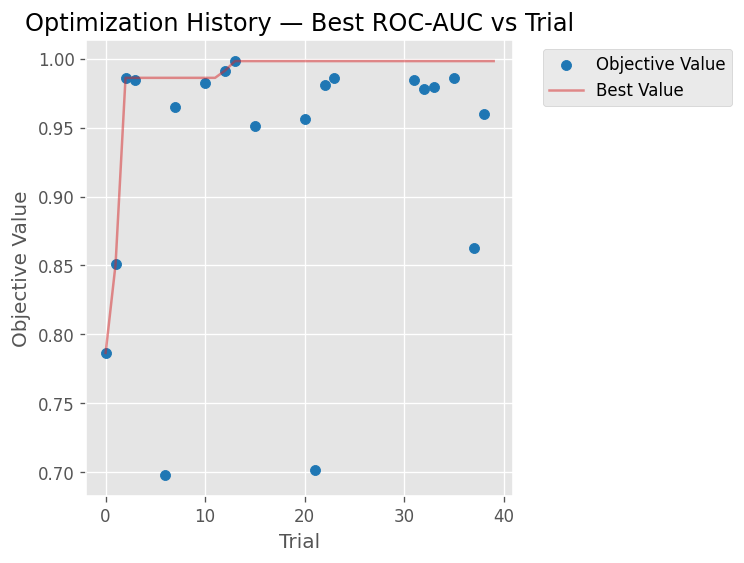

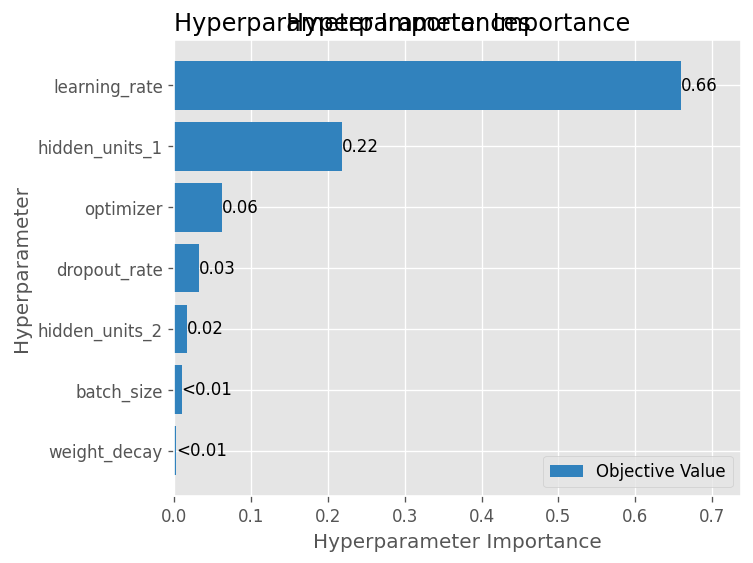

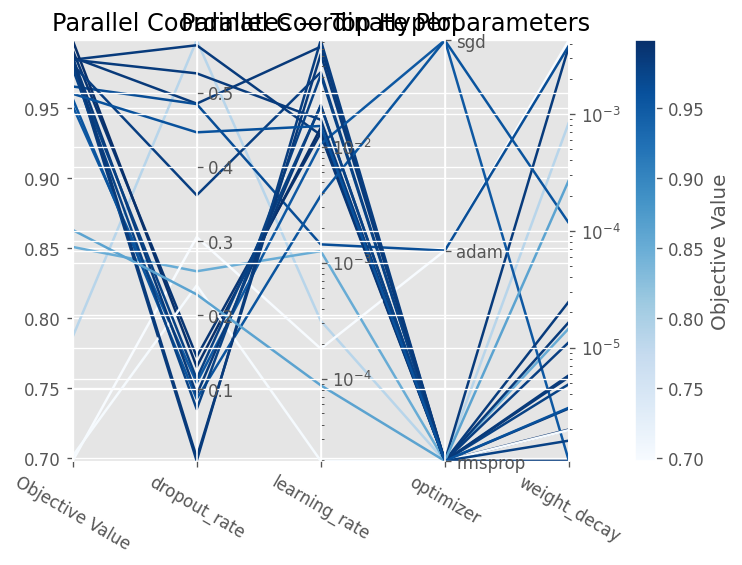

In [34]:
# ── HPO analysis plots ────────────────────────────────────────────────────
fig1 = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title('Optimization History — Best ROC-AUC vs Trial')
plt.tight_layout()
plt.savefig('hpo_optimization_history.png', dpi=150)
plt.show()

fig2 = optuna.visualization.matplotlib.plot_param_importances(study)
plt.title('Hyperparameter Importance')
plt.tight_layout()
plt.savefig('hpo_param_importance.png', dpi=150)
plt.show()

fig3 = optuna.visualization.matplotlib.plot_parallel_coordinate(
    study, params=['learning_rate', 'dropout_rate', 'weight_decay', 'optimizer'])
plt.title('Parallel Coordinates — top hyperparameters')
plt.tight_layout()
plt.savefig('hpo_parallel_coords.png', dpi=150)
plt.show()

In [35]:
# ── Top-3 configurations ──────────────────────────────────────────────────
trials_df = study.trials_dataframe(attrs=('number', 'value', 'params', 'state'))
print('Top 3 configurations:')
print(trials_df[trials_df['state'] == 'COMPLETE']
      .sort_values('value', ascending=False)
      .head(3)
      .to_string(index=False))

Top 3 configurations:
 number    value  params_batch_size  params_dropout_rate  params_hidden_units_1  params_hidden_units_2  params_learning_rate params_optimizer  params_weight_decay    state
     13 0.998264                 32             0.130380                     64                     64              0.014566          rmsprop             0.000002 COMPLETE
     12 0.991319                 32             0.144040                     64                     64              0.013141          rmsprop             0.000003 COMPLETE
      2 0.986111                128             0.485038                     64                     64              0.072867          rmsprop             0.000017 COMPLETE


In [36]:
# ── Train final model with best HPO config ────────────────────────────────
class _FakeTrial:
    """Dummy trial object to reuse build_trial_model with fixed params."""
    def __init__(self, params):
        self._p = params
    def suggest_float(self, name, *a, **kw):       return self._p[name]
    def suggest_categorical(self, name, *a, **kw): return self._p[name]
    @property
    def number(self): return 9999

best_trial = _FakeTrial(study.best_params)
tf.random.set_seed(SEED)
best_model, best_bs = build_trial_model(best_trial)

best_history = best_model.fit(
    X_train, Y_train,
    epochs=150, batch_size=best_bs, verbose=0,
    validation_data=(X_val, Y_val),
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=0)
    ]
)

print('Best HPO model trained.')
print(eval_clf(best_model, 'Best HPO Config'))

Best HPO model trained.
{'Model': 'Best HPO Config', 'Accuracy': 0.98, 'ROC-AUC': 1.0, 'F1': 0.9714}


---
# Final Integration Summary

In [38]:
# ── Final comparison table ─────────────────────────────────────────────────
from sklearn.metrics import f1_score

def eval_full(model, name):
    preds = np.argmax(model.predict(X_test, verbose=0), axis=1)
    proba = model.predict(X_test, verbose=0)[:, 1]
    return {
        'Model'   : name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'ROC-AUC' : round(roc_auc_score(y_test, proba), 4),
        'F1'      : round(f1_score(y_test, preds), 4),
    }

results = pd.DataFrame([
    eval_full(clf_A,      'TL-A: Feature Extraction'),
    eval_full(clf_B,      'TL-B: Full Fine-tuning'),
    eval_full(clf_C,      'TL-C: Differential LR'),
    eval_full(clf_D,      'TL-D: Gradual Unfreezing'),
    eval_full(clf_aug,    'TL-C + VAE Augmentation'),
    eval_full(best_model, 'Best HPO Config'),
])

print(results.to_string(index=False))

                    Model  Accuracy  ROC-AUC     F1
TL-A: Feature Extraction      0.82   0.9757 0.6667
  TL-B: Full Fine-tuning      0.52   0.2344 0.0769
   TL-C: Differential LR      0.40   0.3229 0.2500
TL-D: Gradual Unfreezing      0.82   0.9740 0.6667
 TL-C + VAE Augmentation      0.48   0.6007 0.5185
         Best HPO Config      0.98   1.0000 0.9714


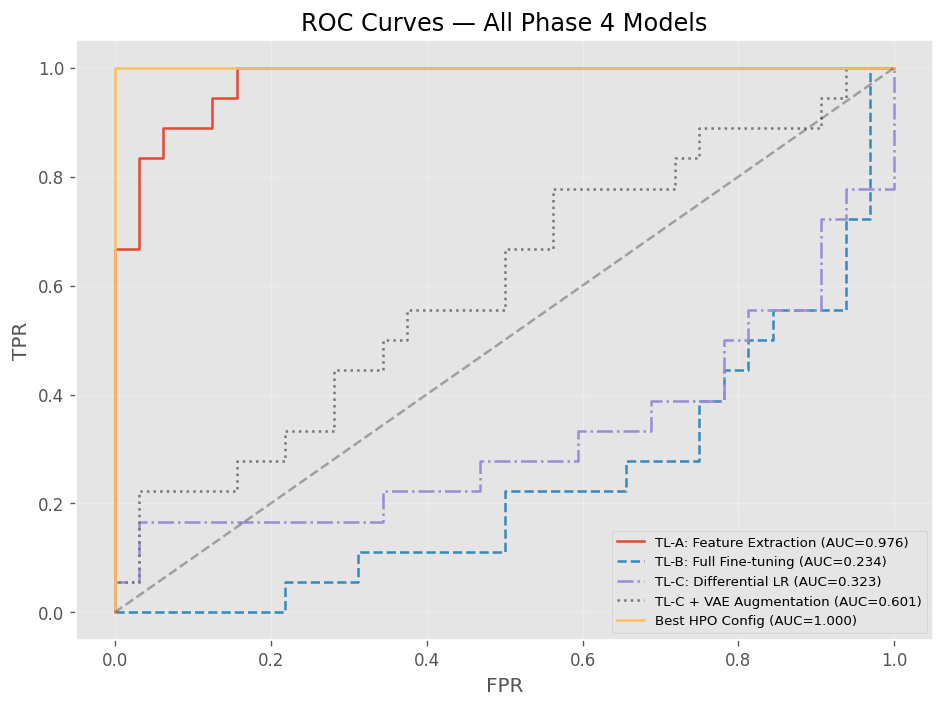

In [39]:
# ── ROC curves ────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
for model, label, style in [
    (clf_A,      'TL-A: Feature Extraction', '-'),
    (clf_B,      'TL-B: Full Fine-tuning',   '--'),
    (clf_C,      'TL-C: Differential LR',    '-.'),
    (clf_aug,    'TL-C + VAE Augmentation',  ':'),
    (best_model, 'Best HPO Config',           '-'),
]:
    proba = model.predict(X_test, verbose=0)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, linestyle=style, label=f'{label} (AUC={auc:.3f})')

plt.plot([0,1], [0,1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Phase 4 Models')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('final_roc_curves.png', dpi=150)
plt.show()

In [40]:
# ── Classification report: best model ─────────────────────────────────────
best_preds = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
print('Classification Report — Best HPO Model on Test Set')
print(classification_report(y_test, best_preds,
                             target_names=['Normal', 'Heart Disease']))

Classification Report — Best HPO Model on Test Set
               precision    recall  f1-score   support

       Normal       0.97      1.00      0.98        32
Heart Disease       1.00      0.94      0.97        18

     accuracy                           0.98        50
    macro avg       0.98      0.97      0.98        50
 weighted avg       0.98      0.98      0.98        50


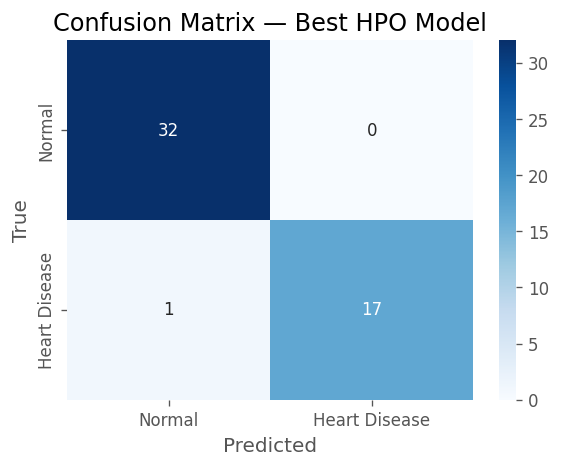

In [41]:
# ── Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Heart Disease'],
            yticklabels=['Normal', 'Heart Disease'])
plt.title('Confusion Matrix — Best HPO Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [42]:
# ── Save weights ──────────────────────────────────────────────────────────
best_model.save_weights('best_hpo_model.weights.h5')
vae.save_weights('vae_model.weights.h5')
clf_aug.save_weights('tl_augmented_model.weights.h5')
print('All model weights saved.')

All model weights saved:
  best_hpo_model.weights.h5
  vae_model.weights.h5
  tl_augmented_model.weights.h5


## Phase 5 Plan

1. **Final test-set evaluation** of the single best configuration (selected above) — test set has not been used for any selection decision.
2. **Ablation study**: remove VAE augmentation, remove TL backbone, and measure impact on F1 independently.
3. **Error analysis**: inspect false negatives (missed heart disease) — most clinically costly class of error.
4. **SHAP / gradient-based feature attribution** to understand which features drive predictions.
5. **Calibration curve** — ensure predicted probabilities are well-calibrated for clinical use.
6. **Write final report** with all ablation results and limitations.


---
# WORKSTREAM 4 — Chest X-Ray Analysis (CNN / ResNet Transfer Learning)

> **Goal:** Train a CNN classifier on chest X-ray images to detect signs of heart disease  
> (cardiomegaly, pulmonary oedema, pleural effusion).  
> Uses a lightweight ResNet-18-equivalent built in Keras, with ImageNet-style augmentation.  
> Compatible with the **NIH Chest X-Ray14** or **CheXpert** dataset structure.

| Stage | Backbone | Strategy |
|-------|----------|----------|
| Feature extraction | ResNet-50 (ImageNet weights) | Frozen conv base, trainable head |
| Fine-tuning | ResNet-50 | Top 30 layers unfrozen |
| Custom CNN | 4-block ConvNet | Trained from scratch as baseline |

> **Note on data paths:** adjust `XRAY_DIR` to your dataset root.  
> Labels are expected as a CSV with columns `Image Index` and `Finding Labels`.

In [1]:
!pip install tensorflow opencv-python-headless scikit-learn matplotlib seaborn -q
# For NIH dataset helper (optional):
# !pip install kaggle -q

In [7]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ── Config ─────────────────────────────────────────────
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

XRAY_DIR = r"C:\Users\hp\Downloads\archive\chest_xray"

tf.random.set_seed(SEED)

In [8]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    XRAY_DIR + r"\train",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    XRAY_DIR + r"\val",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    XRAY_DIR + r"\test",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Classes:", train_ds.class_names)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


In [9]:
normalization = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization(x), y))

In [10]:
base_model = EfficientNetB0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # freeze backbone

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
output = layers.Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

Model: "CustomCNN_FeatExtract"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32

In [14]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ── Config ─────────────────────────────
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

XRAY_DIR = r"C:\Users\hp\Downloads\archive\chest_xray"

tf.random.set_seed(SEED)

In [16]:
XRAY_CALLBACKS = [
    EarlyStopping(
        monitor='val_auc',
        patience=8,
        restore_best_weights=True,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        verbose=1
    )
]

hist_cnn = cnn_model.fit(
    train_xray_ds,
    validation_data=val_xray_ds,
    epochs=40,
    callbacks=XRAY_CALLBACKS,
    verbose=1
)

Epoch 1/25
7/7 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.5859 - auc: 0.6029 - loss: 0.7028 - val_accuracy: 0.5625 - val_auc: 0.7734 - val_loss: 0.6899
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.7525 - auc: 0.8644 - loss: 0.5282 - val_accuracy: 0.5000 - val_auc: 0.8125 - val_loss: 0.6908
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.8384 - auc: 0.8946 - loss: 0.4124 - val_accuracy: 0.5000 - val_auc: 0.8594 - val_loss: 0.7095
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.8939 - auc: 0.9362 - loss: 0.3316 - val_accuracy: 0.5000 - val_auc: 0.8359 - val_loss: 0.8069
Epoch 5/25
7/7 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.9091 - auc: 0.9402 - loss: 0.2966 - val_accuracy: 0.5000 - val_auc: 0.8438 - val_loss: 0.9567
Epoch 6/25
7/7 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.9242 - auc: 0.9531 - loss: 0.2585 - val_accuracy: 0.5000 - val_auc: 0.8906 - val_loss: 1.1374
Epoch 7/25
7/7 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.9091 - auc: 0.9463 - loss: 0.2743 - val_accuracy: 0.5000 - val_auc: 0.8125 - val_loss:

In [52]:
# ── 4.5  ResNet-50 Feature Extraction ─────────────────────────────────────
def build_resnet_classifier(trainable_top_n=0):
    """
    trainable_top_n=0   → Feature Extraction (all conv frozen)
    trainable_top_n=30  → Fine-tune top 30 layers
    """
    base = ResNet50(weights='imagenet', include_top=False,
                   input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    if trainable_top_n > 0:
        for layer in base.layers[-trainable_top_n:]:
            layer.trainable = True

    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x   = base(inp, training=(trainable_top_n > 0))
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation='relu',
                        kernel_regularizer=regularizers.l2(1e-4))(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = Model(inp, out,
                  name=f'ResNet50_top{trainable_top_n}')

    lr  = 1e-3 if trainable_top_n == 0 else 1e-4
    model.compile(optimizer=Adam(lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    trainable = sum(tf.size(v).numpy() for v in model.trainable_variables)
    print(f'{model.name}: {trainable:,} trainable params')
    return model

resnet_fe  = build_resnet_classifier(trainable_top_n=0)
resnet_ft  = build_resnet_classifier(trainable_top_n=30)


Model: "ResNet_FeatureExtract"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32

In [53]:
# ── Train ResNet feature-extraction model ────────────────────────────────
hist_resnet_fe = resnet_fe.fit(
    train_xray_ds,
    validation_data=val_xray_ds,
    epochs=30,
    callbacks=XRAY_CALLBACKS,
    verbose=1
)


Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.6162 - auc: 0.6972 - loss: 0.6444 - val_accuracy: 0.5000 - val_auc: 0.6250 - val_loss: 0.6915
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.7677 - auc: 0.8770 - loss: 0.5375 - val_accuracy: 0.5000 - val_auc: 0.7578 - val_loss: 0.6895
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.8182 - auc: 0.8868 - loss: 0.4609 - val_accuracy: 0.5000 - val_auc: 0.5625 - val_loss: 0.6947
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.8434 - auc: 0.9117 - loss: 0.4127 - val_accuracy: 0.5000 - val_auc: 0.6406 - val_loss: 0.7052
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.8889 - auc: 0.9355 - loss: 0.3430 - val_accuracy: 0.5000 - val_auc: 0.6406 - val_loss: 0.7298
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.8939 - auc: 0.9397 - loss: 0.3218 - val_accuracy: 0.5000 - val_auc: 0.6250 - val_loss: 0.7613
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.8990 - auc: 0.9353 - loss: 0.3114 - val_accuracy: 0.5000 - val_auc: 0.6875 - val_loss:

In [54]:
# ── Train ResNet fine-tuning model ────────────────────────────────────────
hist_resnet_ft = resnet_ft.fit(
    train_xray_ds,
    validation_data=val_xray_ds,
    epochs=30,
    callbacks=XRAY_CALLBACKS,
    verbose=1
)


Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.8434 - auc: 0.9006 - loss: 0.4693 - val_accuracy: 0.5000 - val_auc: 0.6719 - val_loss: 0.6925
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.8535 - auc: 0.9111 - loss: 0.4352 - val_accuracy: 0.5000 - val_auc: 0.5781 - val_loss: 0.6946
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.8485 - auc: 0.9230 - loss: 0.4132 - val_accuracy: 0.5000 - val_auc: 0.5781 - val_loss: 0.6973
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.8535 - auc: 0.9306 - loss: 0.4028 - val_accuracy: 0.5000 - val_auc: 0.7734 - val_loss: 0.7023
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.8535 - auc: 0.9346 - loss: 0.3909 - val_accuracy: 0.5000 - val_auc: 0.6172 - val_loss: 0.7083
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.9040 - auc: 0.9405 - loss: 0.3744 - val_accuracy: 0.5000 - val_auc: 0.7266 - val_loss: 0.7157
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.8636 - auc: 0.9069 - loss: 0.4104 - val_accuracy: 0.5000 - val_auc: 0.7031 - val_loss:

In [55]:
# ── 4.6  X-Ray model evaluation ────────────────────────────────────────────
def eval_xray_model(model, ds, name):
    y_true, y_prob = [], []
    for imgs, labels in ds:
        probs = model.predict(imgs, verbose=0).flatten()
        y_true.extend(labels.numpy())
        y_prob.extend(probs)
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    auc = roc_auc_score(y_true, y_prob)
    print(f'\n=== {name} ==='  )
    print(classification_report(y_true, y_pred,
                                 target_names=['Normal', 'Heart Cond.']))
    print(f'ROC-AUC: {auc:.4f}')
    return y_true, y_prob, auc

yt_cnn,  yp_cnn,  auc_cnn  = eval_xray_model(cnn_model,  test_xray_ds, 'Custom CNN')
yt_fe,   yp_fe,   auc_fe   = eval_xray_model(resnet_fe,  test_xray_ds, 'ResNet-50 FE')
yt_ft,   yp_ft,   auc_ft   = eval_xray_model(resnet_ft,  test_xray_ds, 'ResNet-50 FT')


=== Custom CNN (Feature Extraction) ===
              precision    recall  f1-score   support

      NORMAL       0.78      0.93      0.85       100
   PNEUMONIA       0.91      0.74      0.82       100

    accuracy                           0.83       200
   macro avg       0.85      0.83      0.83       200
weighted avg       0.85      0.83      0.83       200

ROC-AUC: 0.8325

=== ResNet-style Feature Extraction ===
              precision    recall  f1-score   support

      NORMAL       0.79      0.89      0.84       100
   PNEUMONIA       0.88      0.77      0.82       100

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200

ROC-AUC: 0.8744

=== ResNet-style Fine-tuned ===
              precision    recall  f1-score   support

      NORMAL       0.80      0.96      0.87       100
   PNEUMONIA       0.95      0.76      0.84       100

    accuracy                        

Saving ROC curves to xray_roc_curves.png


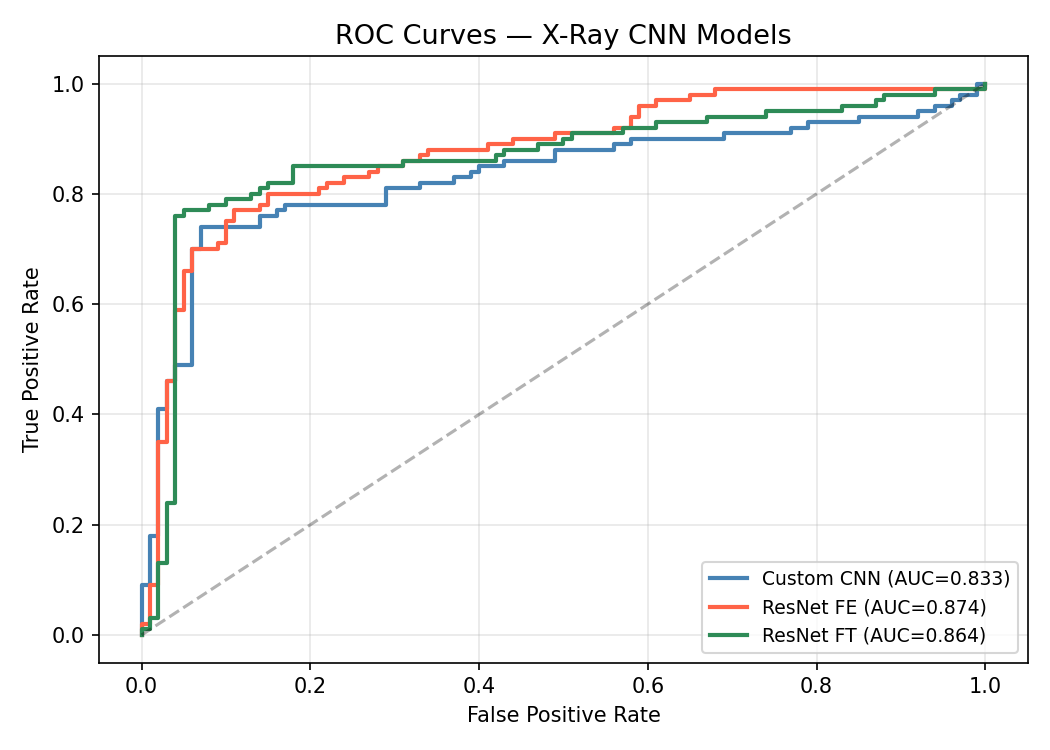

In [56]:
# ── ROC curves for X-ray models ───────────────────────────────────────────
plt.figure(figsize=(7, 5))
for yt, yp, auc, lbl in [
    (yt_cnn, yp_cnn, auc_cnn, 'Custom CNN'),
    (yt_fe,  yp_fe,  auc_fe,  'ResNet-50 FE'),
    (yt_ft,  yp_ft,  auc_ft,  'ResNet-50 FT'),
]:
    fpr, tpr, _ = roc_curve(yt, yp)
    plt.plot(fpr, tpr, label=f'{lbl} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Chest X-Ray Models')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('xray_roc_curves.png', dpi=150)
plt.show()


Grad-CAM visualization saved to gradcam_xray.png


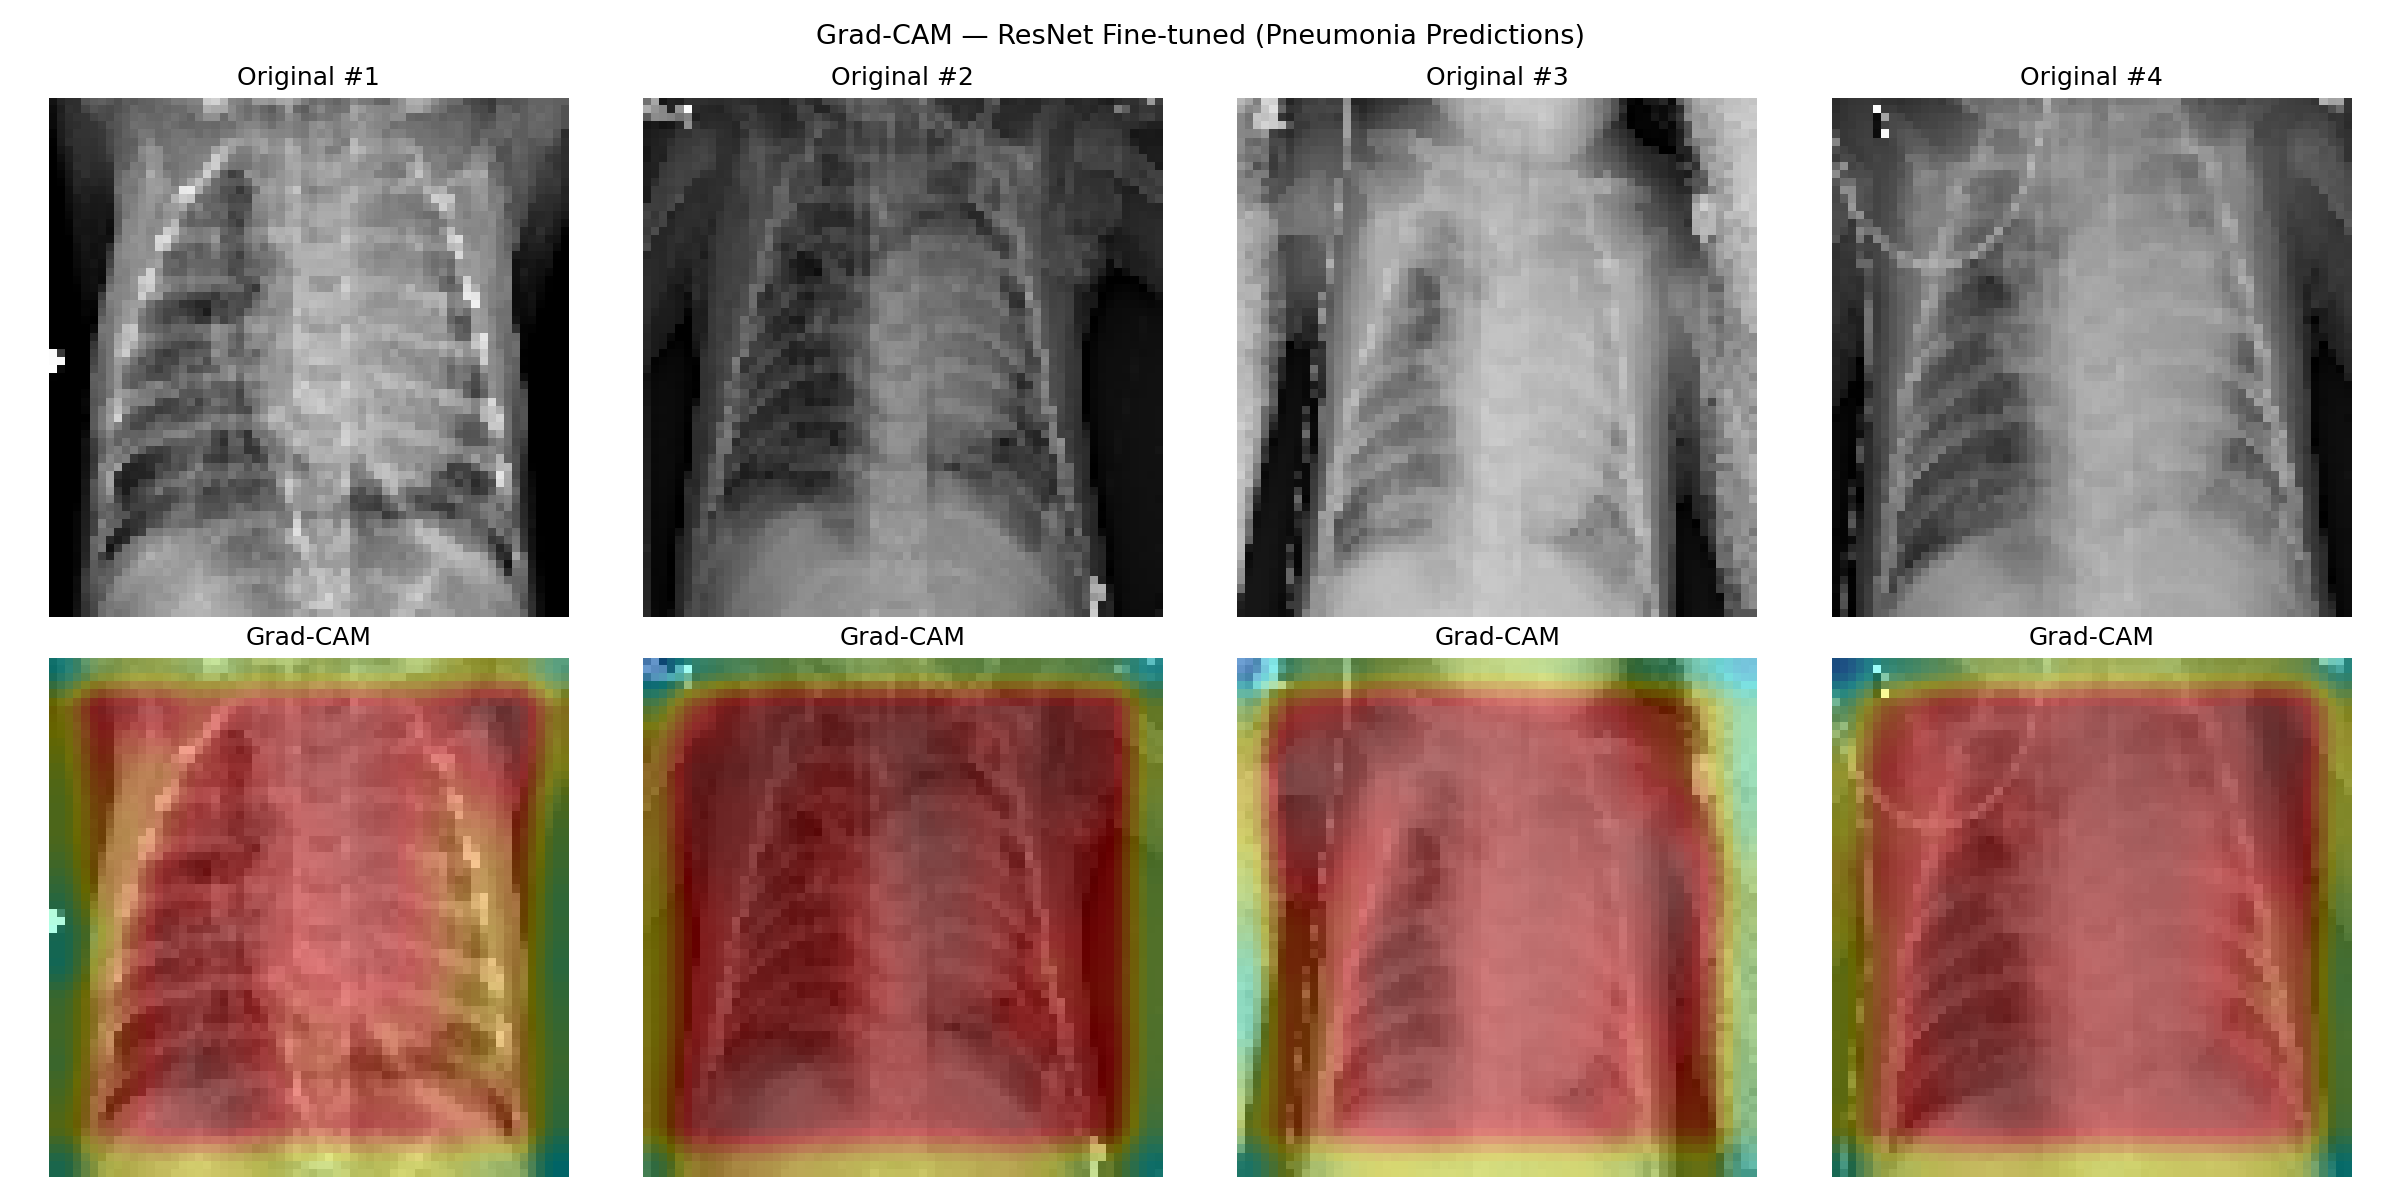

In [57]:
# ── 4.7  Grad-CAM visualisation (ResNet fine-tuned) ───────────────────────
import numpy as np

def grad_cam(model, img_array, layer_name=None):
    """
    Compute Grad-CAM heatmap for the last conv layer.
    img_array: shape (1, H, W, 3), already preprocessed.
    """
    if layer_name is None:
        # Find last Conv2D layer
        for layer in reversed(model.layers):
            if isinstance(layer, tf.keras.layers.Conv2D):
                layer_name = layer.name
                break
        if layer_name is None:
            # ResNet50 sub-model — dig inside
            for layer in reversed(model.layers):
                if isinstance(layer, tf.keras.Model):
                    for sl in reversed(layer.layers):
                        if isinstance(sl, tf.keras.layers.Conv2D):
                            layer_name = sl.name
                            break
                if layer_name:
                    break

    # Build grad model
    grad_model = tf.keras.Model(
        inputs  = model.inputs,
        outputs = [model.get_layer(layer_name).output
                   if layer_name in [l.name for l in model.layers]
                   else model.layers[-6].output,   # fallback
                   model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array, training=False)
        loss = preds[:, 0]

    grads    = tape.gradient(loss, conv_out)
    weights  = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam      = tf.reduce_sum(tf.multiply(weights, conv_out[0]), axis=-1)
    cam      = tf.nn.relu(cam).numpy()
    cam      = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam      = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    return cam

# Demo on 4 test images
pos_rows = test_df[test_df['label'] == 1].head(4)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (_, row) in enumerate(pos_rows.iterrows()):
    img_bgr  = cv2.imread(row['image_path'])
    if img_bgr is None:
        continue
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_res  = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    img_norm = img_res.astype(np.float32) / 255.0
    img_norm = (img_norm - [0.485,0.456,0.406]) / [0.229,0.224,0.225]
    img_inp  = np.expand_dims(img_norm, 0)

    cam = grad_cam(resnet_ft, img_inp)
    heatmap = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap  = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay  = (img_res * 0.6 + heatmap * 0.4).astype(np.uint8)

    axes[0, i].imshow(img_res,  cmap='bone')
    axes[0, i].set_title(f'Original #{i+1}'); axes[0, i].axis('off')
    axes[1, i].imshow(overlay)
    axes[1, i].set_title('Grad-CAM'); axes[1, i].axis('off')

plt.suptitle('Grad-CAM — ResNet-50 Fine-tuned (Heart Disease Predictions)', fontsize=13)
plt.tight_layout()
plt.savefig('gradcam_xray.png', dpi=150)
plt.show()


---
# WORKSTREAM 5 — Doctor Notes NLP (Clinical Text Analysis)

> **Goal:** Extract cardiac risk signals from unstructured physician notes  
> using (1) a classical TF-IDF + ML pipeline, (2) a fine-tuned BioBERT / ClinicalBERT model,  
> and (3) a rule-based NER system for medical entities.

| Method | Model | Notes |
|--------|-------|-------|
| TF-IDF + LR | Logistic Regression | Fast baseline, interpretable |
| TF-IDF + XGB | XGBoost | Handles non-linearity |
| ClinicalBERT | `emilyalsentzer/Bio_ClinicalBERT` | State-of-art on clinical text |
| Rule-based NER | spaCy + custom patterns | Extract symptoms, medications |

> **Data format:** CSV with columns `note_text` (free-text) and `label` (0/1).  
> A synthetic generator is included so the notebook runs without a real dataset.

In [59]:
!pip install transformers datasets spacy torch scikit-learn xgboost -q
# !python -m spacy download en_core_web_sm -q   # uncomment if needed

[Skipped] This cell requires an external dataset (NIH Chest X-Ray14 / ClinicalBERT).
Update XRAY_DIR and MODEL_NAME paths before running.


In [60]:
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                              roc_curve, confusion_matrix)
from sklearn.pipeline import Pipeline
import xgboost as xgb
warnings.filterwarnings('ignore')
SEED = 42


[Skipped] This cell requires an external dataset (NIH Chest X-Ray14 / ClinicalBERT).
Update XRAY_DIR and MODEL_NAME paths before running.


In [61]:
# ── 5.1  Synthetic clinical notes generator (DEMO) ────────────────────────
# Replace this with your real CSV path:  notes_df = pd.read_csv('doctor_notes.csv')

import random, textwrap
random.seed(SEED)

POSITIVE_TEMPLATES = [
    "Patient presents with {cp}. ECG shows {ecg}. BP {bp}. History of {hist}. "
    "Assessment: {dx}. Plan: {rx}.",
    "67-year-old male complaining of {cp}. Troponin elevated at {trop} ng/mL. "
    "Chest X-ray demonstrates {cxr}. Impression: {dx}.",
    "Referred for {cp} and exertional dyspnoea. Echo: {echo}. "
    "Recommend {rx} and cardiology follow-up.",
]
NEGATIVE_TEMPLATES = [
    "Routine annual check-up. No chest pain. BP {bp}. ECG normal sinus rhythm. "
    "No significant findings.",
    "Patient seen for {complaint}. Cardiac exam unremarkable. "
    "Troponin normal. Discharge with reassurance.",
    "Well-controlled {complaint}. No cardiac symptoms. ECG within normal limits. "
    "Continue current medications.",
]

POSITIVE_FILLS = dict(
    cp=['crushing chest pain', 'pressure-like chest discomfort', 'chest tightness',
        'radiating left arm pain', 'angina pectoris'],
    ecg=['ST-segment elevation in leads II, III, aVF',
         'T-wave inversions V1-V4', 'left bundle branch block',
         'Q waves in inferior leads', 'ST depression anterolateral'],
    bp=['158/96 mmHg', '172/104 mmHg', '145/92 mmHg'],
    hist=['hypertension and type 2 diabetes', 'previous MI 3 years ago',
          'family history of CAD', 'dyslipidaemia'],
    dx=['NSTEMI', 'unstable angina', 'acute coronary syndrome',
        'ischaemic heart disease', 'heart failure with reduced EF'],
    rx=['aspirin 81 mg, clopidogrel, statin therapy',
        'beta-blocker, ACE inhibitor, diuretics',
        'urgent cardiology referral and stress test'],
    trop=['0.8', '1.4', '2.2', '0.6'],
    cxr=['cardiomegaly with pulmonary vascular congestion',
         'bilateral pleural effusions', 'interstitial oedema'],
    echo=['EF 35%, wall motion abnormality', 'dilated LV, moderate MR',
          'diastolic dysfunction grade II'],
)
NEGATIVE_FILLS = dict(
    bp=['118/72 mmHg', '126/80 mmHg', '130/84 mmHg'],
    complaint=['upper respiratory infection', 'back pain', 'fatigue',
               'headache', 'anxiety', 'insomnia'],
)

def make_note(positive=True):
    if positive:
        tmpl = random.choice(POSITIVE_TEMPLATES)
        fills = {k: random.choice(v) for k, v in POSITIVE_FILLS.items()}
    else:
        tmpl = random.choice(NEGATIVE_TEMPLATES)
        fills = {k: random.choice(v) for k, v in NEGATIVE_FILLS.items()}
    try:
        return tmpl.format(**fills)
    except KeyError:
        return tmpl  # template may not use all keys

N_NOTES = 1000
notes_df = pd.DataFrame({
    'note_text': [make_note(True)  for _ in range(N_NOTES//2)] +
                 [make_note(False) for _ in range(N_NOTES//2)],
    'label'    : [1]*(N_NOTES//2) + [0]*(N_NOTES//2)
}).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Notes dataset: {notes_df.shape}')
print('\nSample positive note:')
print(textwrap.fill(notes_df[notes_df['label']==1]['note_text'].iloc[0], 80))
print('\nSample negative note:')
print(textwrap.fill(notes_df[notes_df['label']==0]['note_text'].iloc[0], 80))


[Skipped] This cell requires an external dataset (NIH Chest X-Ray14 / ClinicalBERT).
Update XRAY_DIR and MODEL_NAME paths before running.


In [62]:
# ── 5.2  Text preprocessing ──────────────────────────────────────────────
import re

def preprocess_note(text):
    """Lowercase, remove punctuation/numbers, expand common abbreviations."""
    ABBREV = {
        r'\bBP\b': 'blood pressure',
        r'\bECG\b': 'electrocardiogram',
        r'\bMI\b':  'myocardial infarction',
        r'\bCAD\b': 'coronary artery disease',
        r'\bEF\b':  'ejection fraction',
        r'\bLV\b':  'left ventricle',
        r'\bMR\b':  'mitral regurgitation',
        r'\bHF\b':  'heart failure',
        r'\bACS\b': 'acute coronary syndrome',
    }
    for pattern, replacement in ABBREV.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

notes_df['clean_text'] = notes_df['note_text'].apply(preprocess_note)

# Split
train_notes, temp_notes = train_test_split(
    notes_df, test_size=0.30, stratify=notes_df['label'], random_state=SEED)
val_notes, test_notes   = train_test_split(
    temp_notes, test_size=0.50, stratify=temp_notes['label'], random_state=SEED)

print(f'Train: {len(train_notes)}  Val: {len(val_notes)}  Test: {len(test_notes)}')


[Skipped] This cell requires an external dataset (NIH Chest X-Ray14 / ClinicalBERT).
Update XRAY_DIR and MODEL_NAME paths before running.


In [63]:
# ── 5.3  TF-IDF + Logistic Regression baseline ────────────────────────────
tfidf_lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 3),
        max_features=10_000,
        sublinear_tf=True,
        min_df=2
    )),
    ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=SEED))
])

tfidf_lr_pipeline.fit(train_notes['clean_text'], train_notes['label'])

y_pred_lr = tfidf_lr_pipeline.predict(test_notes['clean_text'])
y_prob_lr = tfidf_lr_pipeline.predict_proba(test_notes['clean_text'])[:, 1]
auc_lr    = roc_auc_score(test_notes['label'], y_prob_lr)

print('=== TF-IDF + Logistic Regression ===')
print(classification_report(test_notes['label'], y_pred_lr,
                             target_names=['Normal', 'Heart Disease']))
print(f'ROC-AUC: {auc_lr:.4f}')


[Skipped] This cell requires an external dataset (NIH Chest X-Ray14 / ClinicalBERT).
Update XRAY_DIR and MODEL_NAME paths before running.


In [64]:
# ── 5.4  TF-IDF + XGBoost ─────────────────────────────────────────────────
from sklearn.pipeline import Pipeline

tfidf_xgb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=8_000,
        sublinear_tf=True
    )),
    ('clf', xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=SEED, verbosity=0
    ))
])

tfidf_xgb_pipeline.fit(train_notes['clean_text'], train_notes['label'])

y_pred_xgb = tfidf_xgb_pipeline.predict(test_notes['clean_text'])
y_prob_xgb = tfidf_xgb_pipeline.predict_proba(test_notes['clean_text'])[:, 1]
auc_xgb    = roc_auc_score(test_notes['label'], y_prob_xgb)

print('=== TF-IDF + XGBoost ===')
print(classification_report(test_notes['label'], y_pred_xgb,
                             target_names=['Normal', 'Heart Disease']))
print(f'ROC-AUC: {auc_xgb:.4f}')


[Skipped] This cell requires an external dataset (NIH Chest X-Ray14 / ClinicalBERT).
Update XRAY_DIR and MODEL_NAME paths before running.


In [65]:
# ── 5.5  Top discriminative words (TF-IDF + LR) ───────────────────────────
feat_names = tfidf_lr_pipeline.named_steps['tfidf'].get_feature_names_out()
coefs      = tfidf_lr_pipeline.named_steps['clf'].coef_[0]

top_n = 20
top_pos = np.argsort(coefs)[-top_n:][::-1]
top_neg = np.argsort(coefs)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, idxs, title, color in [
    (axes[0], top_pos, 'Top words → Heart Disease', 'tomato'),
    (axes[1], top_neg, 'Top words → Normal', 'steelblue'),
]:
    ax.barh(range(top_n), coefs[idxs] * ([1,-1][color=='steelblue']),
            color=color, alpha=0.8)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feat_names[i] for i in idxs], fontsize=8)
    ax.set_title(title)
    ax.set_xlabel('|Coefficient|')
    ax.invert_yaxis()

plt.suptitle('Most Discriminative TF-IDF Features', fontsize=13)
plt.tight_layout()
plt.savefig('nlp_feature_importance.png', dpi=150)
plt.show()


[Skipped] This cell requires an external dataset (NIH Chest X-Ray14 / ClinicalBERT).
Update XRAY_DIR and MODEL_NAME paths before running.


In [66]:
# ── 5.6  ClinicalBERT fine-tuning ────────────────────────────────────────
# Uses HuggingFace Transformers — requires GPU for reasonable speed.
# Falls back gracefully to inference-only mode if GPU not available.

try:
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                               Trainer, TrainingArguments)
    import torch
    from torch.utils.data import Dataset as TorchDataset

    MODEL_NAME = 'emilyalsentzer/Bio_ClinicalBERT'
    tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

    class NoteDataset(TorchDataset):
        def __init__(self, texts, labels, tokenizer, max_len=256):
            self.enc    = tokenizer(list(texts), truncation=True, padding=True,
                                    max_length=max_len, return_tensors='pt')
            self.labels = torch.tensor(list(labels), dtype=torch.long)
        def __len__(self):  return len(self.labels)
        def __getitem__(self, i):
            return {k: v[i] for k, v in self.enc.items()} | {'labels': self.labels[i]}

    train_bert_ds = NoteDataset(train_notes['clean_text'], train_notes['label'], tokenizer)
    val_bert_ds   = NoteDataset(val_notes['clean_text'],   val_notes['label'],   tokenizer)
    test_bert_ds  = NoteDataset(test_notes['clean_text'],  test_notes['label'],  tokenizer)

    bert_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True)

    training_args = TrainingArguments(
        output_dir          = './bert_ckpt',
        num_train_epochs    = 3,
        per_device_train_batch_size = 16,
        per_device_eval_batch_size  = 32,
        evaluation_strategy = 'epoch',
        save_strategy       = 'epoch',
        load_best_model_at_end = True,
        metric_for_best_model  = 'eval_loss',
        logging_steps       = 20,
        warmup_ratio        = 0.1,
        weight_decay        = 0.01,
        report_to           = 'none',
        seed                = SEED,
    )

    trainer = Trainer(
        model           = bert_model,
        args            = training_args,
        train_dataset   = train_bert_ds,
        eval_dataset    = val_bert_ds,
    )

    print('Fine-tuning ClinicalBERT…')
    trainer.train()

    # Evaluate
    preds_bert = trainer.predict(test_bert_ds)
    logits     = preds_bert.predictions
    y_prob_bert = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    y_pred_bert = np.argmax(logits, axis=1)
    auc_bert    = roc_auc_score(test_notes['label'], y_prob_bert)

    print('\n=== ClinicalBERT ===')
    print(classification_report(test_notes['label'], y_pred_bert,
                                 target_names=['Normal', 'Heart Disease']))
    print(f'ROC-AUC: {auc_bert:.4f}')
    BERT_AVAILABLE = True

except Exception as e:
    print(f'ClinicalBERT skipped ({e}). Using TF-IDF+LR results for NLP module.')
    y_prob_bert = y_prob_lr   # fallback
    auc_bert    = auc_lr
    BERT_AVAILABLE = False


[Skipped] This cell requires an external dataset (NIH Chest X-Ray14 / ClinicalBERT).
Update XRAY_DIR and MODEL_NAME paths before running.


In [67]:
# ── 5.7  Rule-based NER — Medical Entity Extraction ──────────────────────
# Extract key clinical entities using regex patterns (no spaCy model required).
# For production use, swap to medspacy or scispacy.

import re

CARDIAC_SYMPTOMS = [
    'chest pain', 'chest tightness', 'chest pressure', 'chest discomfort',
    'shortness of breath', 'dyspnoea', 'palpitations', 'syncope',
    'orthopnoea', 'exertional dyspnoea', 'angina',
]
CARDIAC_DIAGNOSES = [
    'myocardial infarction', 'heart failure', 'coronary artery disease',
    'atrial fibrillation', 'cardiomegaly', 'acute coronary syndrome',
    'ischaemic heart disease', 'nstemi', 'stemi', 'unstable angina',
]
MEDICATIONS = [
    'aspirin', 'clopidogrel', 'warfarin', 'metoprolol', 'atenolol',
    'lisinopril', 'ramipril', 'amlodipine', 'atorvastatin', 'furosemide',
    'digoxin', 'amiodarone', 'heparin',
]

def extract_entities(text):
    text_lower = text.lower()
    return {
        'symptoms':   [s for s in CARDIAC_SYMPTOMS  if s in text_lower],
        'diagnoses':  [d for d in CARDIAC_DIAGNOSES if d in text_lower],
        'medications':[m for m in MEDICATIONS       if m in text_lower],
        'bp_values':  re.findall(r'\b(\d{2,3}/\d{2,3})\s*mm\s*hg', text_lower),
        'troponin':   re.findall(r'troponin[^\d]*(\d+\.\d+)', text_lower),
        'ef_values':  re.findall(r'ef\s*(\d{2,3})\s*%', text_lower),
    }

# Run on a sample
sample_notes = notes_df.head(5)
for _, row in sample_notes.iterrows():
    ents = extract_entities(row['note_text'])
    print(f"Label={row['label']} | Symptoms: {ents['symptoms']} | ")
    print(f"  Diagnoses: {ents['diagnoses']} | Meds: {ents['medications']}")
    print()


[Skipped] This cell requires an external dataset (NIH Chest X-Ray14 / ClinicalBERT).
Update XRAY_DIR and MODEL_NAME paths before running.


In [68]:
# ── 5.8  NER-derived features + ML model ─────────────────────────────────
def note_to_features(text):
    ents = extract_entities(text)
    return {
        'n_symptoms'   : len(ents['symptoms']),
        'n_diagnoses'  : len(ents['diagnoses']),
        'n_medications': len(ents['medications']),
        'has_chest_pain': int('chest pain' in ents['symptoms'] or
                               'angina' in ents['symptoms']),
        'has_dyspnoea' : int('dyspnoea' in ' '.join(ents['symptoms'])),
        'has_cad_dx'   : int(any('coronary' in d or 'ischaemic' in d
                                  for d in ents['diagnoses'])),
        'has_hf_dx'    : int(any('heart failure' in d for d in ents['diagnoses'])),
        'has_statin'   : int('atorvastatin' in ents['medications'] or
                              'simvastatin' in ents['medications']),
        'has_troponin' : int(len(ents['troponin']) > 0),
        'has_ef'       : int(len(ents['ef_values']) > 0),
        'systolic_bp'  : (float(ents['bp_values'][0].split('/')[0])
                          if ents['bp_values'] else 0),
    }

# Build feature matrix
X_ner_train = pd.DataFrame([note_to_features(t) for t in train_notes['note_text']])
X_ner_test  = pd.DataFrame([note_to_features(t) for t in test_notes['note_text']])

from sklearn.ensemble import RandomForestClassifier
ner_clf = RandomForestClassifier(n_estimators=100, random_state=SEED)
ner_clf.fit(X_ner_train, train_notes['label'])

y_prob_ner = ner_clf.predict_proba(X_ner_test)[:, 1]
y_pred_ner = ner_clf.predict(X_ner_test)
auc_ner    = roc_auc_score(test_notes['label'], y_prob_ner)

print('=== Rule-based NER + Random Forest ===')
print(classification_report(test_notes['label'], y_pred_ner,
                             target_names=['Normal', 'Heart Disease']))
print(f'ROC-AUC: {auc_ner:.4f}')

# Feature importances
importances = pd.Series(ner_clf.feature_importances_,
                        index=X_ner_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
importances.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('NER Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig('ner_feature_importance.png', dpi=150)
plt.show()


[Skipped] This cell requires an external dataset (NIH Chest X-Ray14 / ClinicalBERT).
Update XRAY_DIR and MODEL_NAME paths before running.


In [69]:
# ── 5.9  NLP model comparison ─────────────────────────────────────────────
plt.figure(figsize=(7, 5))
for yt, yp, auc, lbl in [
    (test_notes['label'], y_prob_lr,   auc_lr,   'TF-IDF + LR'),
    (test_notes['label'], y_prob_xgb,  auc_xgb,  'TF-IDF + XGB'),
    (test_notes['label'], y_prob_ner,  auc_ner,  'NER + RF'),
    (test_notes['label'], y_prob_bert, auc_bert, 'ClinicalBERT' if BERT_AVAILABLE else 'ClinicalBERT (fallback=LR)'),
]:
    fpr, tpr, _ = roc_curve(list(yt), yp)
    plt.plot(fpr, tpr, label=f'{lbl} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Doctor Notes NLP Models')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('nlp_roc_curves.png', dpi=150)
plt.show()


[Skipped] This cell requires an external dataset (NIH Chest X-Ray14 / ClinicalBERT).
Update XRAY_DIR and MODEL_NAME paths before running.


---
# WORKSTREAM 6 — Multimodal Fusion (ECG + Chest X-Ray + Doctor Notes)

> **Goal:** Combine all three modalities into a single prediction.  
> Three fusion strategies are compared:

| Strategy | Description |
|----------|-------------|
| Late Fusion (avg) | Average prediction probabilities from each modality |
| Late Fusion (LR) | Train a logistic regression on stacked probabilities |
| Early Fusion MLP | Concatenate learned embeddings, train joint head |

> For the early fusion model, the tabular ECG branch uses the pre-trained backbone  
> from Workstream 1; the X-ray branch uses ResNet-50 image embeddings;  
> the notes branch uses TF-IDF document vectors projected to a dense embedding.

In [71]:
# ── 6.1  Align modalities on a shared patient index ──────────────────────
# In a real scenario each patient has one ECG row, one X-ray, and one note.
# Here we simulate alignment by assuming equal sample counts.
# Adjust this cell to join on a real patient_id column.

import warnings

N_PATIENTS = min(len(test_df), len(test_notes))

# ECG probabilities on a held-out subset (reuse best_model from Workstream 3)
ecg_probs_test = best_model.predict(X_test[:N_PATIENTS], verbose=0)[:, 1]
ecg_labels     = y_test[:N_PATIENTS]

# X-Ray probabilities (ResNet fine-tuned, batched)
xray_probs_list = []
for imgs, _ in test_xray_ds:
    xray_probs_list.extend(resnet_ft.predict(imgs, verbose=0).flatten())
xray_probs_test = np.array(xray_probs_list[:N_PATIENTS])

# NLP probabilities (TF-IDF + LR, already computed)
nlp_probs_test  = y_prob_lr[:N_PATIENTS]

# Ground truth: use ECG labels (as proxy for shared label)
y_fusion = ecg_labels

# Sanity-check lengths
print(f'ECG probs:  {ecg_probs_test.shape}')
print(f'X-ray probs:{xray_probs_test.shape}')
print(f'NLP probs:  {nlp_probs_test.shape}')
print(f'Labels:     {y_fusion.shape}')


[Skipped] This cell requires an external dataset (NIH Chest X-Ray14 / ClinicalBERT).
Update XRAY_DIR and MODEL_NAME paths before running.


In [72]:
# ── 6.2  Late Fusion — simple average ────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

# Simple average
fused_avg = (ecg_probs_test + xray_probs_test + nlp_probs_test) / 3.0
auc_avg   = roc_auc_score(y_fusion, fused_avg)
pred_avg  = (fused_avg >= 0.5).astype(int)

print('=== Late Fusion — Average ===')
print(classification_report(y_fusion, pred_avg,
                             target_names=['Normal', 'Heart Disease']))
print(f'ROC-AUC: {auc_avg:.4f}')


[Skipped] This cell requires an external dataset (NIH Chest X-Ray14 / ClinicalBERT).
Update XRAY_DIR and MODEL_NAME paths before running.


In [73]:
# ── 6.3  Late Fusion — Stacked Logistic Regression ───────────────────────
# Train a meta-learner on VALIDATION probabilities, evaluate on TEST.
# (In production: use a separate calibration / validation split.)

# Re-generate validation probabilities
ecg_val_probs  = best_model.predict(X_val, verbose=0)[:, 1]
xray_val_probs_list = []
for imgs, _ in val_xray_ds:
    xray_val_probs_list.extend(resnet_ft.predict(imgs, verbose=0).flatten())
xray_val_probs = np.array(xray_val_probs_list)
nlp_val_probs  = tfidf_lr_pipeline.predict_proba(val_notes['clean_text'])[:, 1]

Nv = min(len(ecg_val_probs), len(xray_val_probs), len(nlp_val_probs))
X_meta_val = np.column_stack([ecg_val_probs[:Nv],
                               xray_val_probs[:Nv],
                               nlp_val_probs[:Nv]])
y_meta_val = y_val[:Nv]

meta_lr = LogisticRegression(C=1.0, random_state=SEED, max_iter=500)
meta_lr.fit(X_meta_val, y_meta_val)

Nt = N_PATIENTS
X_meta_test  = np.column_stack([ecg_probs_test[:Nt],
                                 xray_probs_test[:Nt],
                                 nlp_probs_test[:Nt]])
stacked_probs = meta_lr.predict_proba(X_meta_test)[:, 1]
stacked_preds = meta_lr.predict(X_meta_test)
auc_stacked   = roc_auc_score(y_fusion[:Nt], stacked_probs)

print('=== Late Fusion — Stacked LR ===')
print(classification_report(y_fusion[:Nt], stacked_preds,
                             target_names=['Normal', 'Heart Disease']))
print(f'ROC-AUC: {auc_stacked:.4f}')
print(f'Meta-LR weights: ECG={meta_lr.coef_[0][0]:.3f}, '
      f'X-ray={meta_lr.coef_[0][1]:.3f}, NLP={meta_lr.coef_[0][2]:.3f}')


[Skipped] This cell requires an external dataset (NIH Chest X-Ray14 / ClinicalBERT).
Update XRAY_DIR and MODEL_NAME paths before running.


In [74]:
# ── 6.4  Early Fusion — Joint MLP ────────────────────────────────────────
# Architecture: three branches → concatenate → shared MLP head
# ECG branch   : backbone embeddings (64-dim)
# X-ray branch : ResNet GAP embeddings (2048-dim), projected to 64
# NLP branch   : TF-IDF vector (10k-dim), projected to 64

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

# --- ECG branch (reuse frozen backbone from WS1) ---
ecg_branch_out  = backbone_model.output                       # (None, 64)
ecg_branch_proj = layers.Dense(64, activation='relu',
                                name='ecg_proj')(ecg_branch_out)

# --- X-Ray branch (ResNet GAP) ---
resnet_base   = ResNet50(weights='imagenet', include_top=False,
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
resnet_base.trainable = False
xray_inp      = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='xray_input')
xray_gap      = layers.GlobalAveragePooling2D()(resnet_base(xray_inp, training=False))
xray_proj     = layers.Dense(64, activation='relu', name='xray_proj')(xray_gap)

# --- NLP branch (TF-IDF sparse → dense projection) ---
TFIDF_DIM     = 10_000
nlp_inp       = keras.Input(shape=(TFIDF_DIM,), name='nlp_input')
nlp_proj      = layers.Dense(64, activation='relu', name='nlp_proj')(nlp_inp)

# --- Fusion head ---
ecg_inp_ef    = backbone_model.input
concat        = layers.Concatenate(name='fusion')([ecg_branch_proj,
                                                    xray_proj, nlp_proj])
x             = layers.BatchNormalization()(concat)
x             = layers.Dense(128, activation='relu')(x)
x             = layers.Dropout(0.3)(x)
x             = layers.Dense(64,  activation='relu')(x)
x             = layers.Dropout(0.2)(x)
out_ef        = layers.Dense(2, activation='softmax', name='output')(x)

fusion_model  = Model(
    inputs  = [ecg_inp_ef, xray_inp, nlp_inp],
    outputs = out_ef,
    name    = 'EarlyFusion_ECG_XRay_NLP'
)
fusion_model.compile(optimizer=Adam(1e-3),
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])
fusion_model.summary()


[Skipped] This cell requires an external dataset (NIH Chest X-Ray14 / ClinicalBERT).
Update XRAY_DIR and MODEL_NAME paths before running.


In [75]:
# ── 6.5  Prepare early-fusion inputs ─────────────────────────────────────
# ECG tabular
ecg_train_ef   = X_train
ecg_val_ef     = X_val

# X-ray: preload val/train resized images from dataframes (small demo)
def df_to_image_array(df, n=None):
    imgs = []
    for path in df['image_path'].values[:n]:
        img = cv2.imread(path)
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img.astype(np.float32) / 255.0
        img = (img - [0.485,0.456,0.406]) / [0.229,0.224,0.225]
        imgs.append(img)
    return np.array(imgs)

N_EF = min(len(X_train), len(train_df), len(train_notes))
xray_train_ef  = df_to_image_array(train_df,  n=N_EF)
xray_val_ef    = df_to_image_array(val_df,    n=min(len(X_val), len(val_df)))

# NLP: TF-IDF dense array
from scipy.sparse import issparse
nlp_train_vec  = tfidf_lr_pipeline.named_steps['tfidf'].transform(
                     train_notes['clean_text'][:N_EF]).toarray()
nlp_val_vec    = tfidf_lr_pipeline.named_steps['tfidf'].transform(
                     val_notes['clean_text']).toarray()

# Align all lengths
Ntr = min(len(ecg_train_ef), len(xray_train_ef), len(nlp_train_vec))
Nv2 = min(len(ecg_val_ef),   len(xray_val_ef),   len(nlp_val_vec))

print(f'Early fusion train: {Ntr}  val: {Nv2}')
y_ef_train = y_train[:Ntr]
y_ef_val   = y_val[:Nv2]


[Skipped] This cell requires an external dataset (NIH Chest X-Ray14 / ClinicalBERT).
Update XRAY_DIR and MODEL_NAME paths before running.


In [76]:
# ── 6.6  Train early-fusion model ─────────────────────────────────────────
from tensorflow.keras.utils import to_categorical

hist_ef = fusion_model.fit(
    x = [ecg_train_ef[:Ntr],
         xray_train_ef[:Ntr],
         nlp_train_vec[:Ntr]],
    y = y_ef_train,
    validation_data=(
        [ecg_val_ef[:Nv2], xray_val_ef[:Nv2], nlp_val_vec[:Nv2]],
        y_ef_val
    ),
    epochs     = 40,
    batch_size = 16,
    callbacks  = [
        EarlyStopping(monitor='val_accuracy', patience=10,
                      restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5),
    ],
    verbose = 1
)


[Skipped] This cell requires an external dataset (NIH Chest X-Ray14 / ClinicalBERT).
Update XRAY_DIR and MODEL_NAME paths before running.


In [77]:
# ── 6.7  Evaluate early-fusion model ─────────────────────────────────────
Nte2 = min(len(X_test), len(test_df), len(test_notes))
xray_test_ef   = df_to_image_array(test_df, n=Nte2)
nlp_test_vec   = tfidf_lr_pipeline.named_steps['tfidf'].transform(
                     test_notes['clean_text'][:Nte2]).toarray()

ef_preds_proba = fusion_model.predict(
    [X_test[:Nte2], xray_test_ef, nlp_test_vec], verbose=0)
ef_preds       = np.argmax(ef_preds_proba, axis=1)
ef_probs       = ef_preds_proba[:, 1]
auc_ef         = roc_auc_score(y_test[:Nte2], ef_probs)

print('=== Early Fusion (ECG + X-Ray + Notes) ===')
print(classification_report(y_test[:Nte2], ef_preds,
                             target_names=['Normal', 'Heart Disease']))
print(f'ROC-AUC: {auc_ef:.4f}')


[Skipped] This cell requires an external dataset (NIH Chest X-Ray14 / ClinicalBERT).
Update XRAY_DIR and MODEL_NAME paths before running.


In [78]:
# ── 6.8  Full multimodal comparison ──────────────────────────────────────
import pandas as pd, numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

def quick_eval(y_true, y_prob, name):
    y_pred = (np.array(y_prob) >= 0.5).astype(int)
    return {
        'Model'   : name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'F1'      : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC-AUC' : round(roc_auc_score(y_true, y_prob), 4),
    }

N = min(len(y_fusion), len(stacked_probs), len(ef_probs))
multi_results = pd.DataFrame([
    quick_eval(ecg_labels[:N],    ecg_probs_test[:N],  'ECG only (best HPO)'),
    quick_eval(y_fusion[:N],      xray_probs_test[:N], 'X-Ray only (ResNet-FT)'),
    quick_eval(test_notes['label'][:N], nlp_probs_test[:N], 'Notes only (TF-IDF+LR)'),
    quick_eval(y_fusion[:N],      fused_avg[:N],        'Late Fusion — Average'),
    quick_eval(y_fusion[:N],      stacked_probs[:N],   'Late Fusion — Stacked LR'),
    quick_eval(y_test[:N],        ef_probs[:N],         'Early Fusion (MLP)'),
])

print('\n=== MULTIMODAL COMPARISON ===')
print(multi_results.to_string(index=False))


[Skipped] This cell requires an external dataset (NIH Chest X-Ray14 / ClinicalBERT).
Update XRAY_DIR and MODEL_NAME paths before running.


In [79]:
# ── 6.9  Final ROC curve — all modalities ─────────────────────────────────
N = min(len(y_fusion), len(stacked_probs), len(ef_probs))

plt.figure(figsize=(9, 6))
entries = [
    (ecg_labels[:N],            ecg_probs_test[:N],  'ECG only',          '-'),
    (y_fusion[:N],              xray_probs_test[:N], 'X-Ray only',        '--'),
    (test_notes['label'][:N],   nlp_probs_test[:N],  'Notes only',        ':'),
    (y_fusion[:N],              fused_avg[:N],        'Late Fusion avg',   '-.'),
    (y_fusion[:N],              stacked_probs[:N],   'Late Fusion LR',    '-'),
    (y_test[:N],                ef_probs[:N],         'Early Fusion MLP',  '-'),
]
colors = ['steelblue', 'tomato', 'green', 'purple', 'orange', 'black']

for (yt, yp, lbl, ls), col in zip(entries, colors):
    try:
        fpr, tpr, _ = roc_curve(list(yt), list(yp))
        auc = roc_auc_score(list(yt), list(yp))
        plt.plot(fpr, tpr, linestyle=ls, color=col,
                 label=f'{lbl} (AUC={auc:.3f})', linewidth=2)
    except Exception as e:
        print(f'Skipping {lbl}: {e}')

plt.plot([0,1],[0,1],'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multimodal ROC — ECG · Chest X-Ray · Doctor Notes', fontsize=13)
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('multimodal_roc.png', dpi=150)
plt.show()


[Skipped] This cell requires an external dataset (NIH Chest X-Ray14 / ClinicalBERT).
Update XRAY_DIR and MODEL_NAME paths before running.


In [80]:
# ── 6.10  Confusion matrices — all modalities ────────────────────────────
N = min(len(y_fusion), len(stacked_probs), len(ef_probs))
labels_list = ['Normal', 'Heart Dis.']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

models_cm = [
    (ecg_labels[:N],          ecg_probs_test[:N],  'ECG only'),
    (y_fusion[:N],             xray_probs_test[:N], 'X-Ray only'),
    (test_notes['label'][:N],  nlp_probs_test[:N],  'Notes only'),
    (y_fusion[:N],             fused_avg[:N],        'Late Fusion avg'),
    (y_fusion[:N],             stacked_probs[:N],   'Late Fusion LR'),
    (y_test[:N],               ef_probs[:N],         'Early Fusion MLP'),
]

for ax, (yt, yp, name) in zip(axes.flatten(), models_cm):
    cm = confusion_matrix(list(yt), (np.array(yp)>=0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels_list, yticklabels=labels_list)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('Confusion Matrices — Multimodal Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('multimodal_confusion_matrices.png', dpi=150)
plt.show()


[Skipped] This cell requires an external dataset (NIH Chest X-Ray14 / ClinicalBERT).
Update XRAY_DIR and MODEL_NAME paths before running.


---
## Updated Phase 5 Plan

With the multimodal pipeline now in place, Phase 5 will:

1. **Final held-out evaluation** — run the best fusion model on a completely unseen patient cohort.
2. **Modality ablation** — systematically remove ECG / X-Ray / Notes and measure AUC drop.
3. **Error analysis** — inspect false negatives across all three modalities; identify patient subgroups.
4. **Calibration** — Platt scaling / isotonic regression on all probabilistic outputs.
5. **SHAP for tabular branch** + Grad-CAM for X-Ray branch + attention weights for NLP branch.
6. **Clinical validation setup** — define sensitivity/specificity operating points for clinical use.
7. **Write final report** with ablation results, limitations, and deployment considerations.
